In [42]:
import scipy.io
import io

from data_loader import DataLoader

import numpy as np
from utils import *
from matplotlib import pyplot as plt
import numpy.random as rng
import pandas as pd

import os
import math

In [43]:
home_dir = os.path.abspath(os.path.curdir)
data_dir = os.path.join(home_dir, '..', 'Data')
ultralight = os.path.join(data_dir, 'GG-Dataset-Tulio-Ultralight')

print(os.path.abspath(home_dir))
print(os.path.abspath(data_dir))
print(os.path.abspath(ultralight))

/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/URI-project
/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/Data
/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/Data/GG-Dataset-Tulio-Ultralight


In [44]:
def load_data(rats):
    return DataLoader(data_dir, 'Hpc', rats=[rats])
    
rats = ['Rat08', 'Rat09', 'Rat10', 'Rat11']
rat_id = 0
rat = rats[rat_id] 
area ='all'

#load data
data = load_data(rat)
spks = data.get_spk()
pos = data._get_pos()

/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/URI-project/data_loader.py:402: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/Data/Rat08/Rat08-20130722/States.mat
  self.__warning_msg(self.paths[rat][session]['States'])
/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/URI-project/data_loader.py:592: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/Data/Rat08/Rat08-20130722/Rat08-20130722.rip.evt
  self.__warning_msg(path)
/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/URI-project/data_loader.py:592: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/Data/Rat08/Rat08-20130718/Rat08-20130718.rip.evt
  self.__warning_msg(path)
/Users/madeliefvanmeggelen/Documents/Rad

**Preprocessing functions**

In [45]:
def session_variable(session_idx):
    sessions_data = list(data.events[rat].keys())
    sessions_spks = list(spks[rat].keys()) 

    sessions = np.intersect1d(sessions_spks, sessions_data)
    sessions.sort()
    session = sessions[session_idx]

    session_neurons = spks[rat][session][area]
    neuron_ids = list(spks[rat][session][area].keys())
    n_neurons = len(neuron_ids)

    begin_run_i = int(list(data.events[rat][session]['cat']['data']).index('beginning run'))
    end_run_i = int(list(data.events[rat][session]['cat']['data']).index('end run'))

    begin_run_t = int(list(data.events[rat][session]['cat']['ts'])[begin_run_i])
    end_run_t = int(list(data.events[rat][session]['cat']['ts'])[end_run_i])
    
    return neuron_ids, n_neurons, session, session_neurons, begin_run_t, end_run_t

In [46]:
def position_variable(session):
    x = data.position[rat][session]['x']
    y = data.position[rat][session]['y']
    time_location = data.position[rat][session]['Time']

    # location_run_idx = [index for index, t in enumerate(time_location) if t > begin_run_t and t < end_run_t]

    # x_run = x[location_run_idx[0]:location_run_idx[-1]]
    # y_run = y[location_run_idx[0]:location_run_idx[-1]]
    run_indices = (time_location >= begin_run_t) & (time_location <= end_run_t)
    x_run = x[run_indices]
    y_run = y[run_indices]
    time_run = time_location[run_indices]

    # Find the puff events and location
    puff_events_ = data.events[rat][session]['puf']['ts']
    puff_events = []
    
    # Make sure the puff events are an int format (some sessions consist of strings)
    if isinstance(list(puff_events_)[0], str):
        for t in np.array(puff_events_):
            puff_events.append(float(t[:14]))
    else:
        puff_events = puff_events_

    # Filter puff events to run session
    puff_events = [t for t in puff_events if t > begin_run_t and t < end_run_t]
    
    
    puff_x_location = [x_run[np.absolute(time_location-i).argmin()] for i in puff_events]
    puff_y_location = [y_run[np.absolute(time_location-i).argmin()] for i in puff_events]

    # Find the mean of the puff location
    x_mean = np.mean(puff_x_location)

    return x, y, time_location, x_run, y_run, time_run, puff_events, puff_x_location, puff_y_location, x_mean

In [47]:
def preprocess_rewards(left_reward_ts_, right_reward_ts_, begin_run_t, end_run_t, time_run):
    def process_timestamps(raw_ts):
        """
        Process and filter timestamps, keeping the indices of the rewards within the time_loc range.
        """
        processed_ts_with_indices = []
        # Ensure all timestamps are floats
        if isinstance(raw_ts[0], str):
            raw_ts = [float(t[:14]) for t in raw_ts]
        
        # Keep timestamps within the time range
        for reward_ts in raw_ts:
            if begin_run_t <= reward_ts <= end_run_t:
                # Find the index of the time_loc closest to the reward timestamp
                closest_idx = np.abs(time_run - reward_ts).argmin()
                processed_ts_with_indices.append((reward_ts, closest_idx))  # Tuple of (reward timestamp, index in time_loc)
        
        return processed_ts_with_indices

    # Process left and right reward timestamps
    left_reward_ts = process_timestamps(left_reward_ts_)
    right_reward_ts = process_timestamps(right_reward_ts_)

    return left_reward_ts, right_reward_ts

In [48]:
def get_test_and_train_runs(safe_runs_matrix):
    train_runs = []
    test_runs = []
    
    for i, val in enumerate (safe_runs_matrix):
        if i % 2:
            train_runs.append(safe_runs_matrix[i])
        else :
            test_runs.append(safe_runs_matrix[i])
        train_runs_matrix = np.array(train_runs)
        test_runs_matrix = np.array(test_runs)
    return train_runs_matrix, test_runs_matrix

**First try at looping**

In [49]:
%run Preprocessing_Track_Data_Functions.ipynb
%run New_Preprocessing_Track_Data_Functions.ipynb
%run MI_Analysis_and_Sequence_Function.ipynb


In [50]:
sessions = spks[rats[rat_id]].keys() #get the keys of the dictionary spks
content = spks[rats[rat_id]].values() #values of the dictionary spks
print(len(sessions))

neuron_ids, n_neurons, session, session_neurons, begin_run_t, end_run_t = session_variable(int(2))
print(n_neurons)

9
55


In [51]:
spk_sessions = list(spks[rats[rat_id]].keys()) #get the keys of the dictionary spks
data_sessions = list(data.events[rat].keys())
union_sessions = list(set(spk_sessions) | set(data_sessions))
print(union_sessions)

['Rat08-20130715', 'Rat08-20130717', 'Rat08-20130716', 'Rat08-20130720', 'Rat08-20130709', 'Rat08-20130712', 'Rat08-20130708', 'Rat08-20130718', 'Rat08-20130710', 'Rat08-20130711', 'Rat08-20130722', 'Rat08-20130713']


In [52]:
# Initialize an empty list to store matrices
session_matrices = []
valid_sessions = np.zeros(len(sessions))
session_attributes = []
n_iterations= 500
n_neurons_session = []

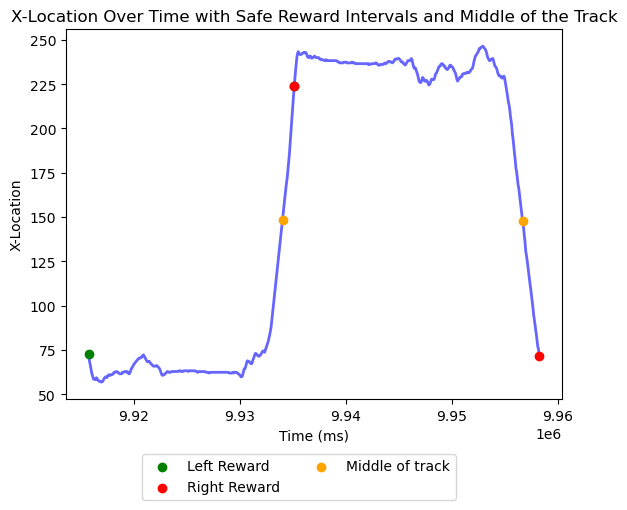

Rat08-20130708


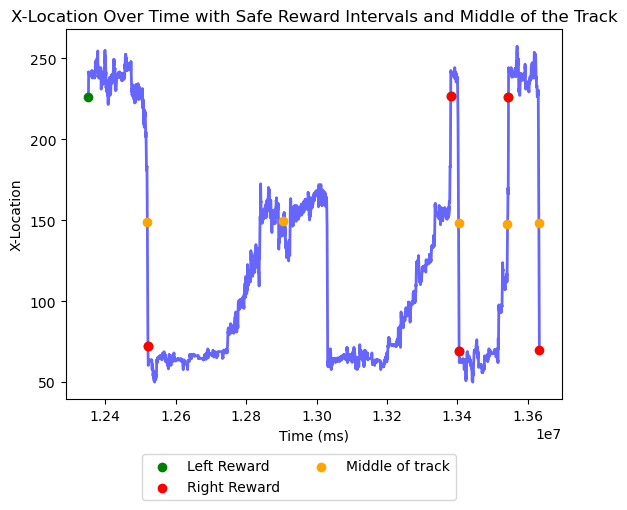

Rat08-20130709


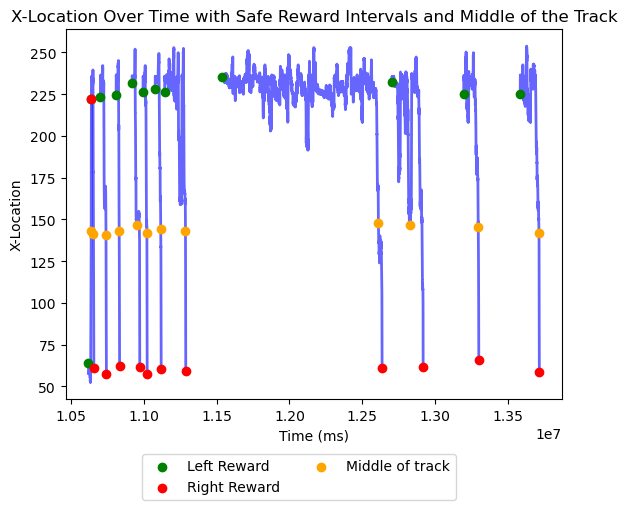

Rat08-20130712


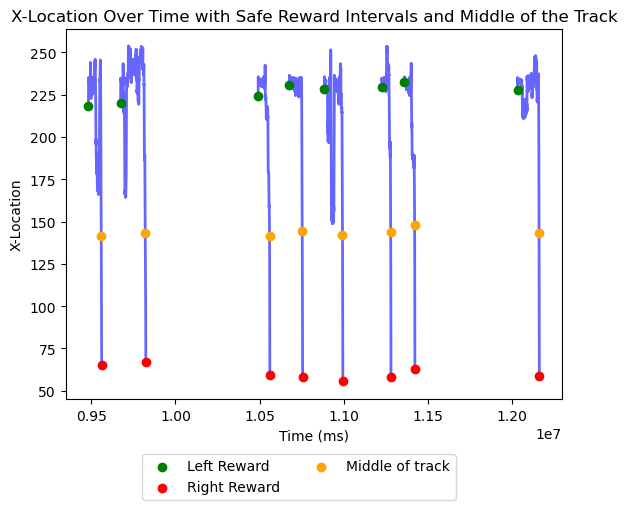

Rat08-20130713


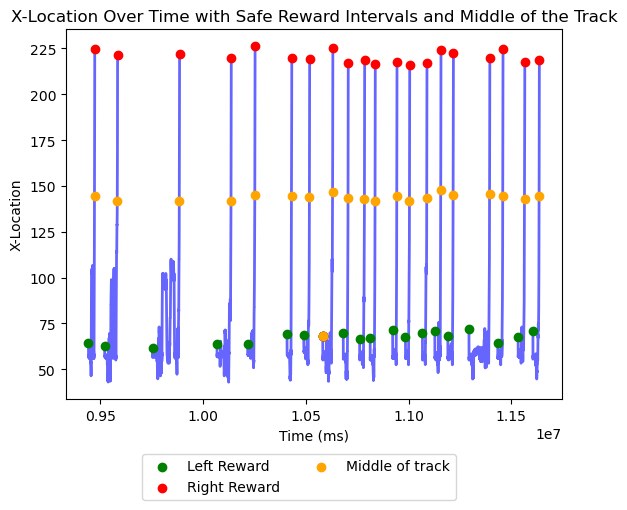

Rat08-20130715


In [53]:
session_data_rat8_middle_split= {}
for i in range(5):
    # Initialize variables for session
    neuron_ids, n_neurons, session, session_neurons, begin_run_t, end_run_t = session_variable(int(i))
    n_neurons_session.append(n_neurons)
    x, y, time_location, x_run, y_run, time_run, puff_ts, puff_x_location, puff_y_location, x_mean = position_variable(session)
    left_reward_times = data.events[rat][session]['lrw']['ts']
    right_reward_times = data.events[rat][session]['rrw']['ts']
    left_reward_ts, right_reward_ts = preprocess_rewards(left_reward_times, right_reward_times, begin_run_t, end_run_t, time_run)

    # Get the matrix for the current session
    safe_runs_without_middle = exclude_airpuff_periods_matrix(left_reward_ts, right_reward_ts, puff_ts)
    safe_runs_WITH_middle = safe_runs_with_middle(safe_runs_without_middle, x_run)
    plot_safe_runs_with_middle(safe_runs_WITH_middle, x_run, time_run)
    session_matrices.append(safe_runs_WITH_middle)

    test_matrix, train_matrix = get_test_and_train_runs(safe_runs_WITH_middle)
    spk_matrix_train = init_spk_matrix_train_safe_runs(train_matrix, session, n_neurons, neuron_ids, session_neurons)
    print(session)
    session_data_rat8_middle_split[session] = {
        "test_matrix": test_matrix,
        "train_matrix": train_matrix,
        "session_neurons": session_neurons,
        "n_neurons": n_neurons,
        "neuron_ids": neuron_ids
    }



In [55]:
print(n_neurons_session)
import pickle
with open("rat8_session_data_middle.pkl", "wb") as pkl_file:
    pickle.dump(session_data_rat8_middle_split, pkl_file)

[8, 28, 55, 55, 19]


In [56]:
session_data_rat8_third_split= {}
for i in range(5):
    neuron_ids, n_neurons, session, session_neurons, begin_run_t, end_run_t = session_variable(int(i))
    x, y, time_location, x_run, y_run, time_run, puff_ts, puff_x_location, puff_y_location, x_mean = position_variable(session)
    left_reward_times = data.events[rat][session]['lrw']['ts']
    right_reward_times = data.events[rat][session]['rrw']['ts']
    left_reward_ts, right_reward_ts = preprocess_rewards(left_reward_times, right_reward_times, begin_run_t, end_run_t, time_run)

    # Get the matrix for the current session
    safe_runs_without_third = exclude_airpuff_periods_matrix(left_reward_ts, right_reward_ts, puff_ts)
    safe_runs_WITH_third = safe_runs_with_third(safe_runs_without_third, x_run)
    # plot_safe_runs_with_third(safe_runs_WITH_third, x_run, time_run)
    session_matrices.append(safe_runs_WITH_third)

    test_matrix, train_matrix = get_test_and_train_runs(safe_runs_WITH_third)
    spk_matrix_train = init_spk_matrix_train_safe_runs(train_matrix, session, n_neurons, neuron_ids, session_neurons)
    print(session)
    session_data_rat8_third_split[session] = {
        "test_matrix": test_matrix,
        "train_matrix": train_matrix,
        "session_neurons": session_neurons,
        "n_neurons": n_neurons,
        "neuron_ids": neuron_ids
    }



Rat08-20130708
Rat08-20130709
Rat08-20130712
Rat08-20130713
Rat08-20130715


In [46]:
results_per_session_rat8_middle_split = {}

In [47]:
for session, matrices in session_data_rat8_middle_split.items():
    print(f'Analyzing session {session}')
    test_matrix = matrices["test_matrix"]
    train_matrix = matrices["train_matrix"]
    n_neurons = matrices ["n_neurons"]
    neuron_ids = matrices ["neuron_ids"]
    session_neurons = matrices["session_neurons"]
    
    spk_matrix_train = init_spk_matrix_train_safe_runs(train_matrix, session, n_neurons, neuron_ids, session_neurons)
    
    occ, mi_real, surrogates, boundary = compute_mi_occ_surrogates_per_neuron(spk_matrix_train, 120, 500)
    
    results_per_session_rat8_middle_split[session] = {
        "occ": occ,
        "mi_real": mi_real,
        "surrogates": surrogates,
        "boundary": boundary
    }
    print(f'On to next session')

Analyzing session Rat08-20130708
Analyzing neuron 0 of 8
Computed ranks, occ, mi and surrogates for  0 of 8
Analyzing neuron 1 of 8
Computed ranks, occ, mi and surrogates for  1 of 8
Analyzing neuron 2 of 8
Computed ranks, occ, mi and surrogates for  2 of 8
Analyzing neuron 3 of 8
Computed ranks, occ, mi and surrogates for  3 of 8
Analyzing neuron 4 of 8
Computed ranks, occ, mi and surrogates for  4 of 8
Analyzing neuron 5 of 8
Computed ranks, occ, mi and surrogates for  5 of 8
Analyzing neuron 6 of 8
Computed ranks, occ, mi and surrogates for  6 of 8
Analyzing neuron 7 of 8
Computed ranks, occ, mi and surrogates for  7 of 8
On to next session
Analyzing session Rat08-20130709
Analyzing neuron 0 of 28
Computed ranks, occ, mi and surrogates for  0 of 28
Analyzing neuron 1 of 28
Computed ranks, occ, mi and surrogates for  1 of 28
Analyzing neuron 2 of 28
Computed ranks, occ, mi and surrogates for  2 of 28
Analyzing neuron 3 of 28
Computed ranks, occ, mi and surrogates for  3 of 28
Analyzi

In [22]:
results_per_session_rat8_third_split = {}

In [23]:
for session, matrices in session_data_rat8_third_split.items():
    print(f'Analyzing session {session}')
    test_matrix = matrices["test_matrix"]
    train_matrix = matrices["train_matrix"]
    n_neurons = matrices ["n_neurons"]
    neuron_ids = matrices ["neuron_ids"]
    session_neurons = matrices["session_neurons"]
    
    spk_matrix_train = init_spk_matrix_train_safe_runs(train_matrix, session, n_neurons, neuron_ids, session_neurons)
    
    occ, mi_real, surrogates, boundary = compute_mi_occ_surrogates_per_neuron(spk_matrix_train, 120, 500)
    
    results_per_session_rat8_third_split[session] = {
        "occ": occ,
        "mi_real": mi_real,
        "surrogates": surrogates,
        "boundary": boundary
    }
    print(f'On to next session')

Analyzing session Rat08-20130708
Analyzing neuron 0 of 8
Computed ranks, occ, mi and surrogates for  0 of 8
Analyzing neuron 1 of 8
Computed ranks, occ, mi and surrogates for  1 of 8
Analyzing neuron 2 of 8
Computed ranks, occ, mi and surrogates for  2 of 8
Analyzing neuron 3 of 8
Computed ranks, occ, mi and surrogates for  3 of 8
Analyzing neuron 4 of 8
Computed ranks, occ, mi and surrogates for  4 of 8
Analyzing neuron 5 of 8
Computed ranks, occ, mi and surrogates for  5 of 8
Analyzing neuron 6 of 8
Computed ranks, occ, mi and surrogates for  6 of 8
Analyzing neuron 7 of 8
Computed ranks, occ, mi and surrogates for  7 of 8
On to next session
Analyzing session Rat08-20130709
Analyzing neuron 0 of 28
Computed ranks, occ, mi and surrogates for  0 of 28
Analyzing neuron 1 of 28
Computed ranks, occ, mi and surrogates for  1 of 28
Analyzing neuron 2 of 28
Computed ranks, occ, mi and surrogates for  2 of 28
Analyzing neuron 3 of 28
Computed ranks, occ, mi and surrogates for  3 of 28
Analyzi

/var/folders/gx/7pdzybf540s07y1q49gzn5400000gn/T/ipykernel_6305/4014550263.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


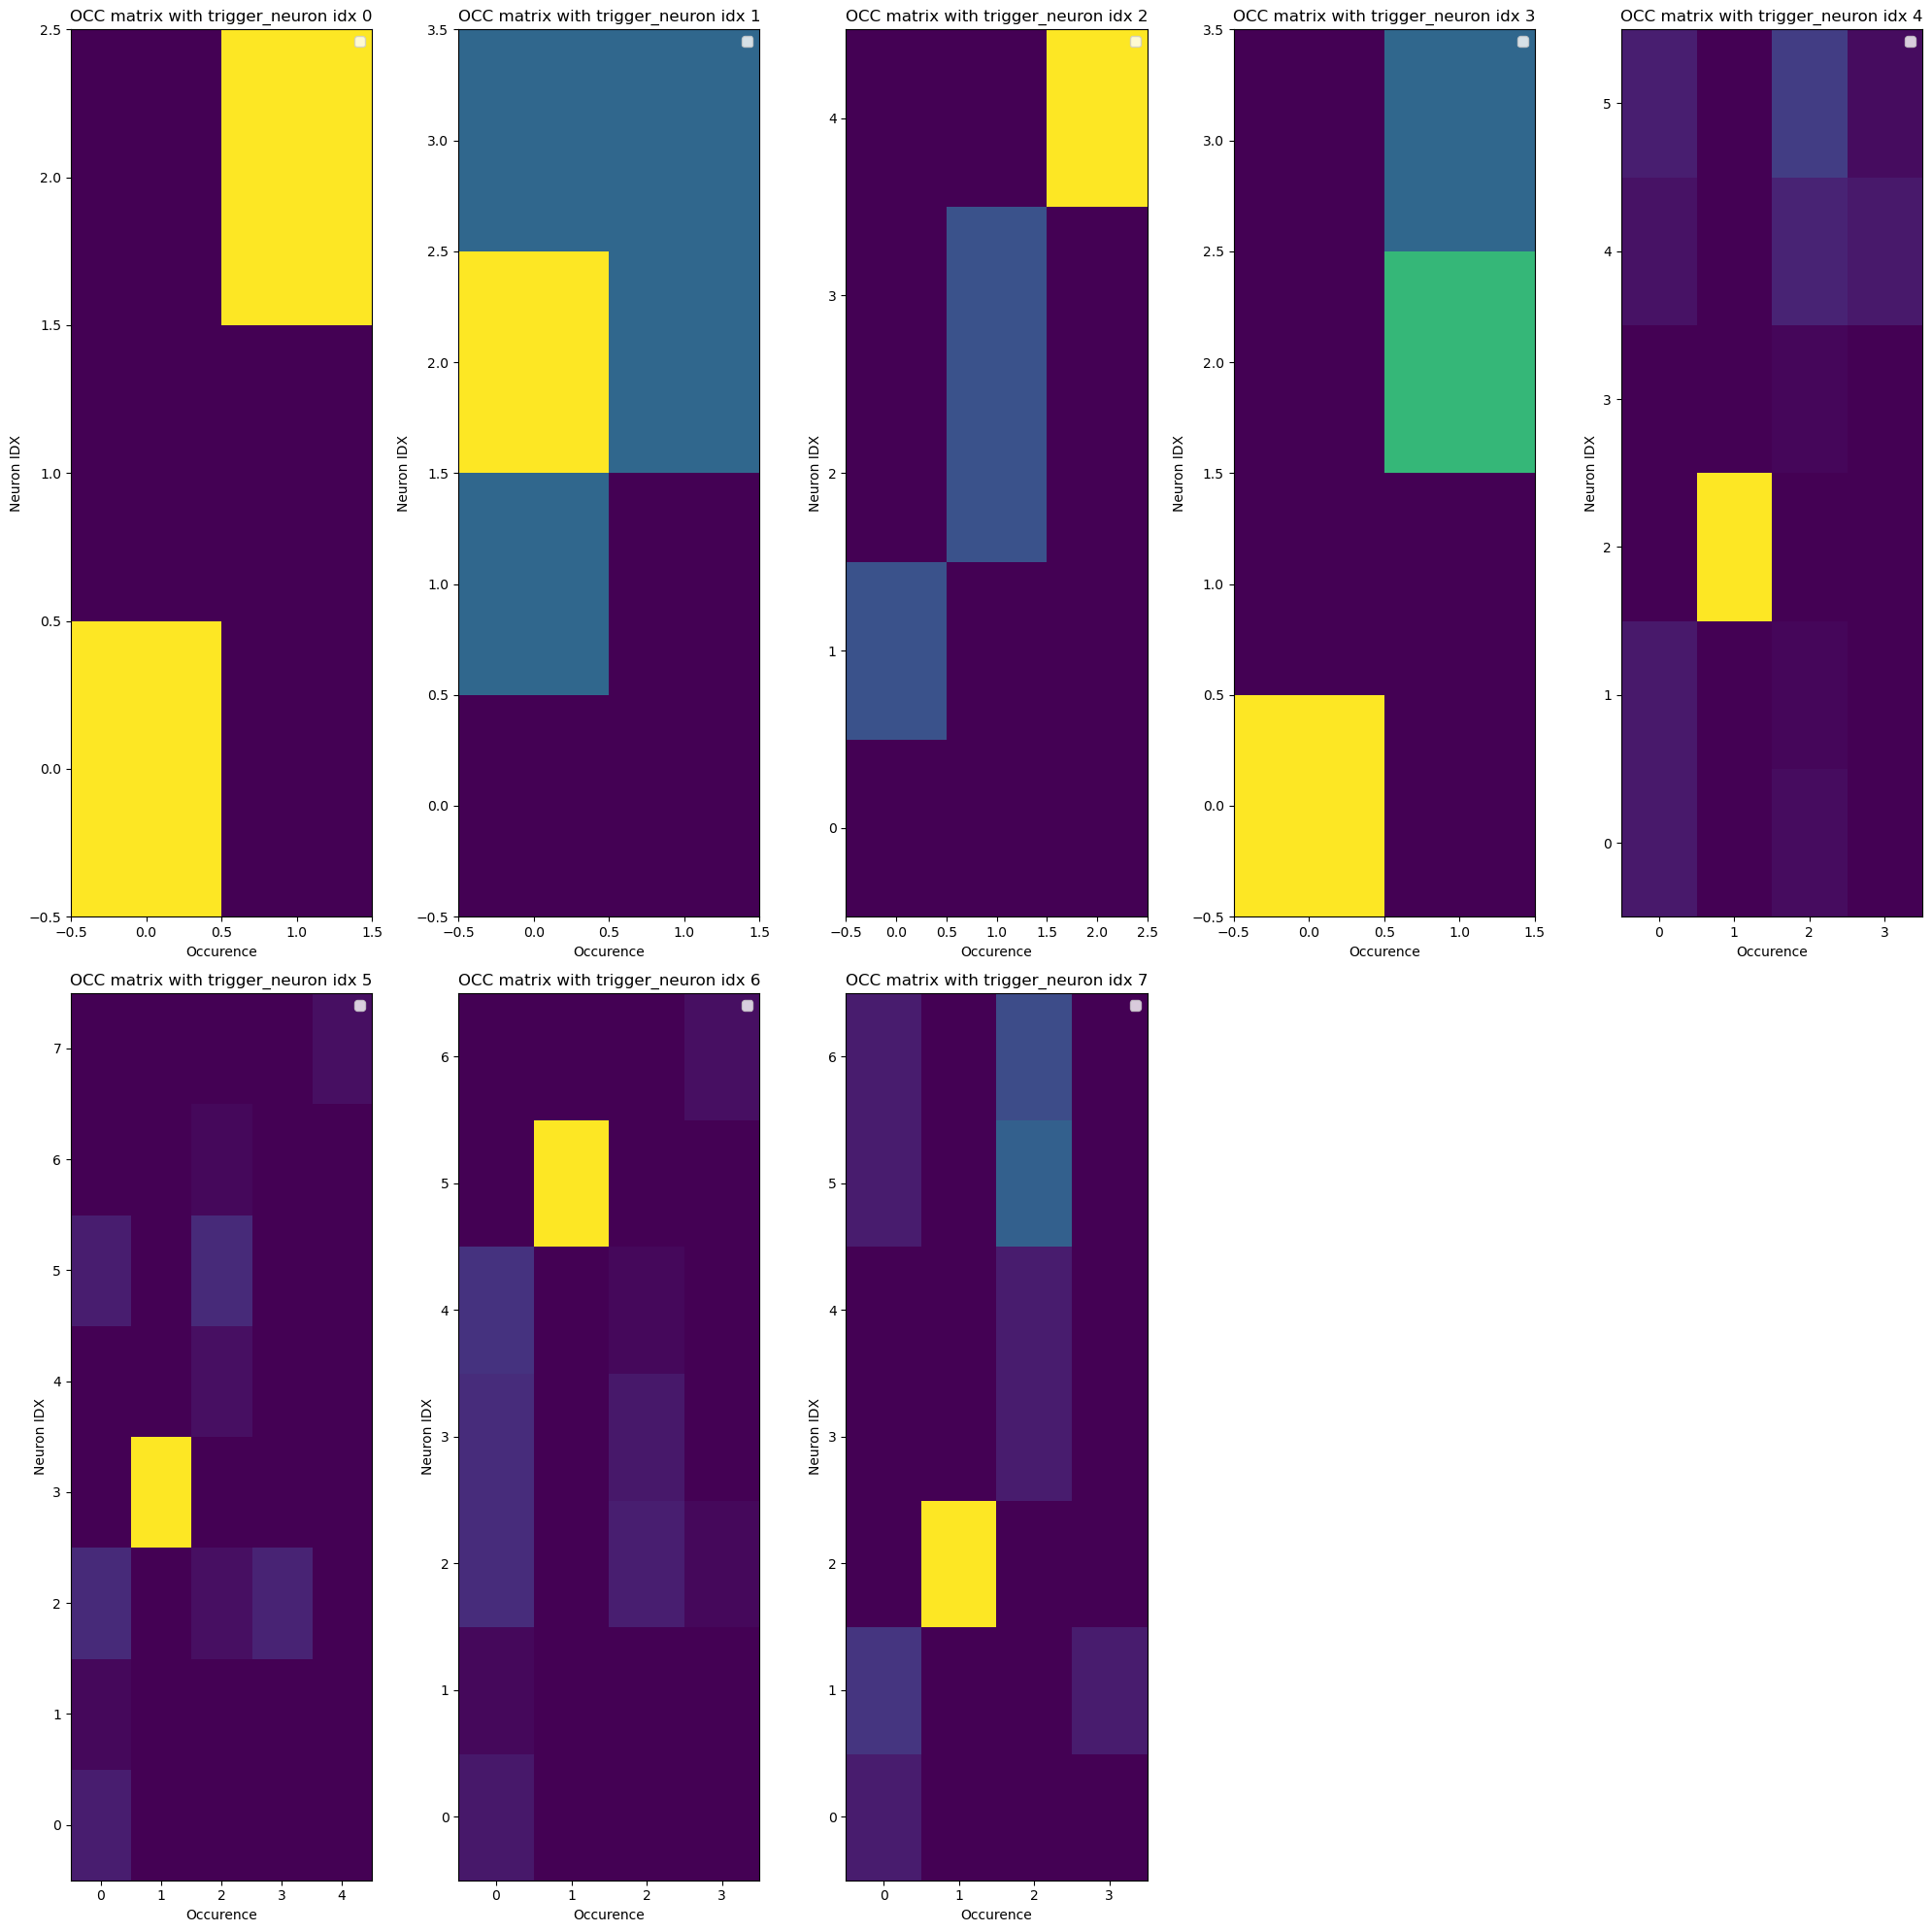

/var/folders/gx/7pdzybf540s07y1q49gzn5400000gn/T/ipykernel_6305/4014550263.py:7: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.imshow(sort_occ_matrix(occ_matrix)[0], aspect='auto', origin='lower')


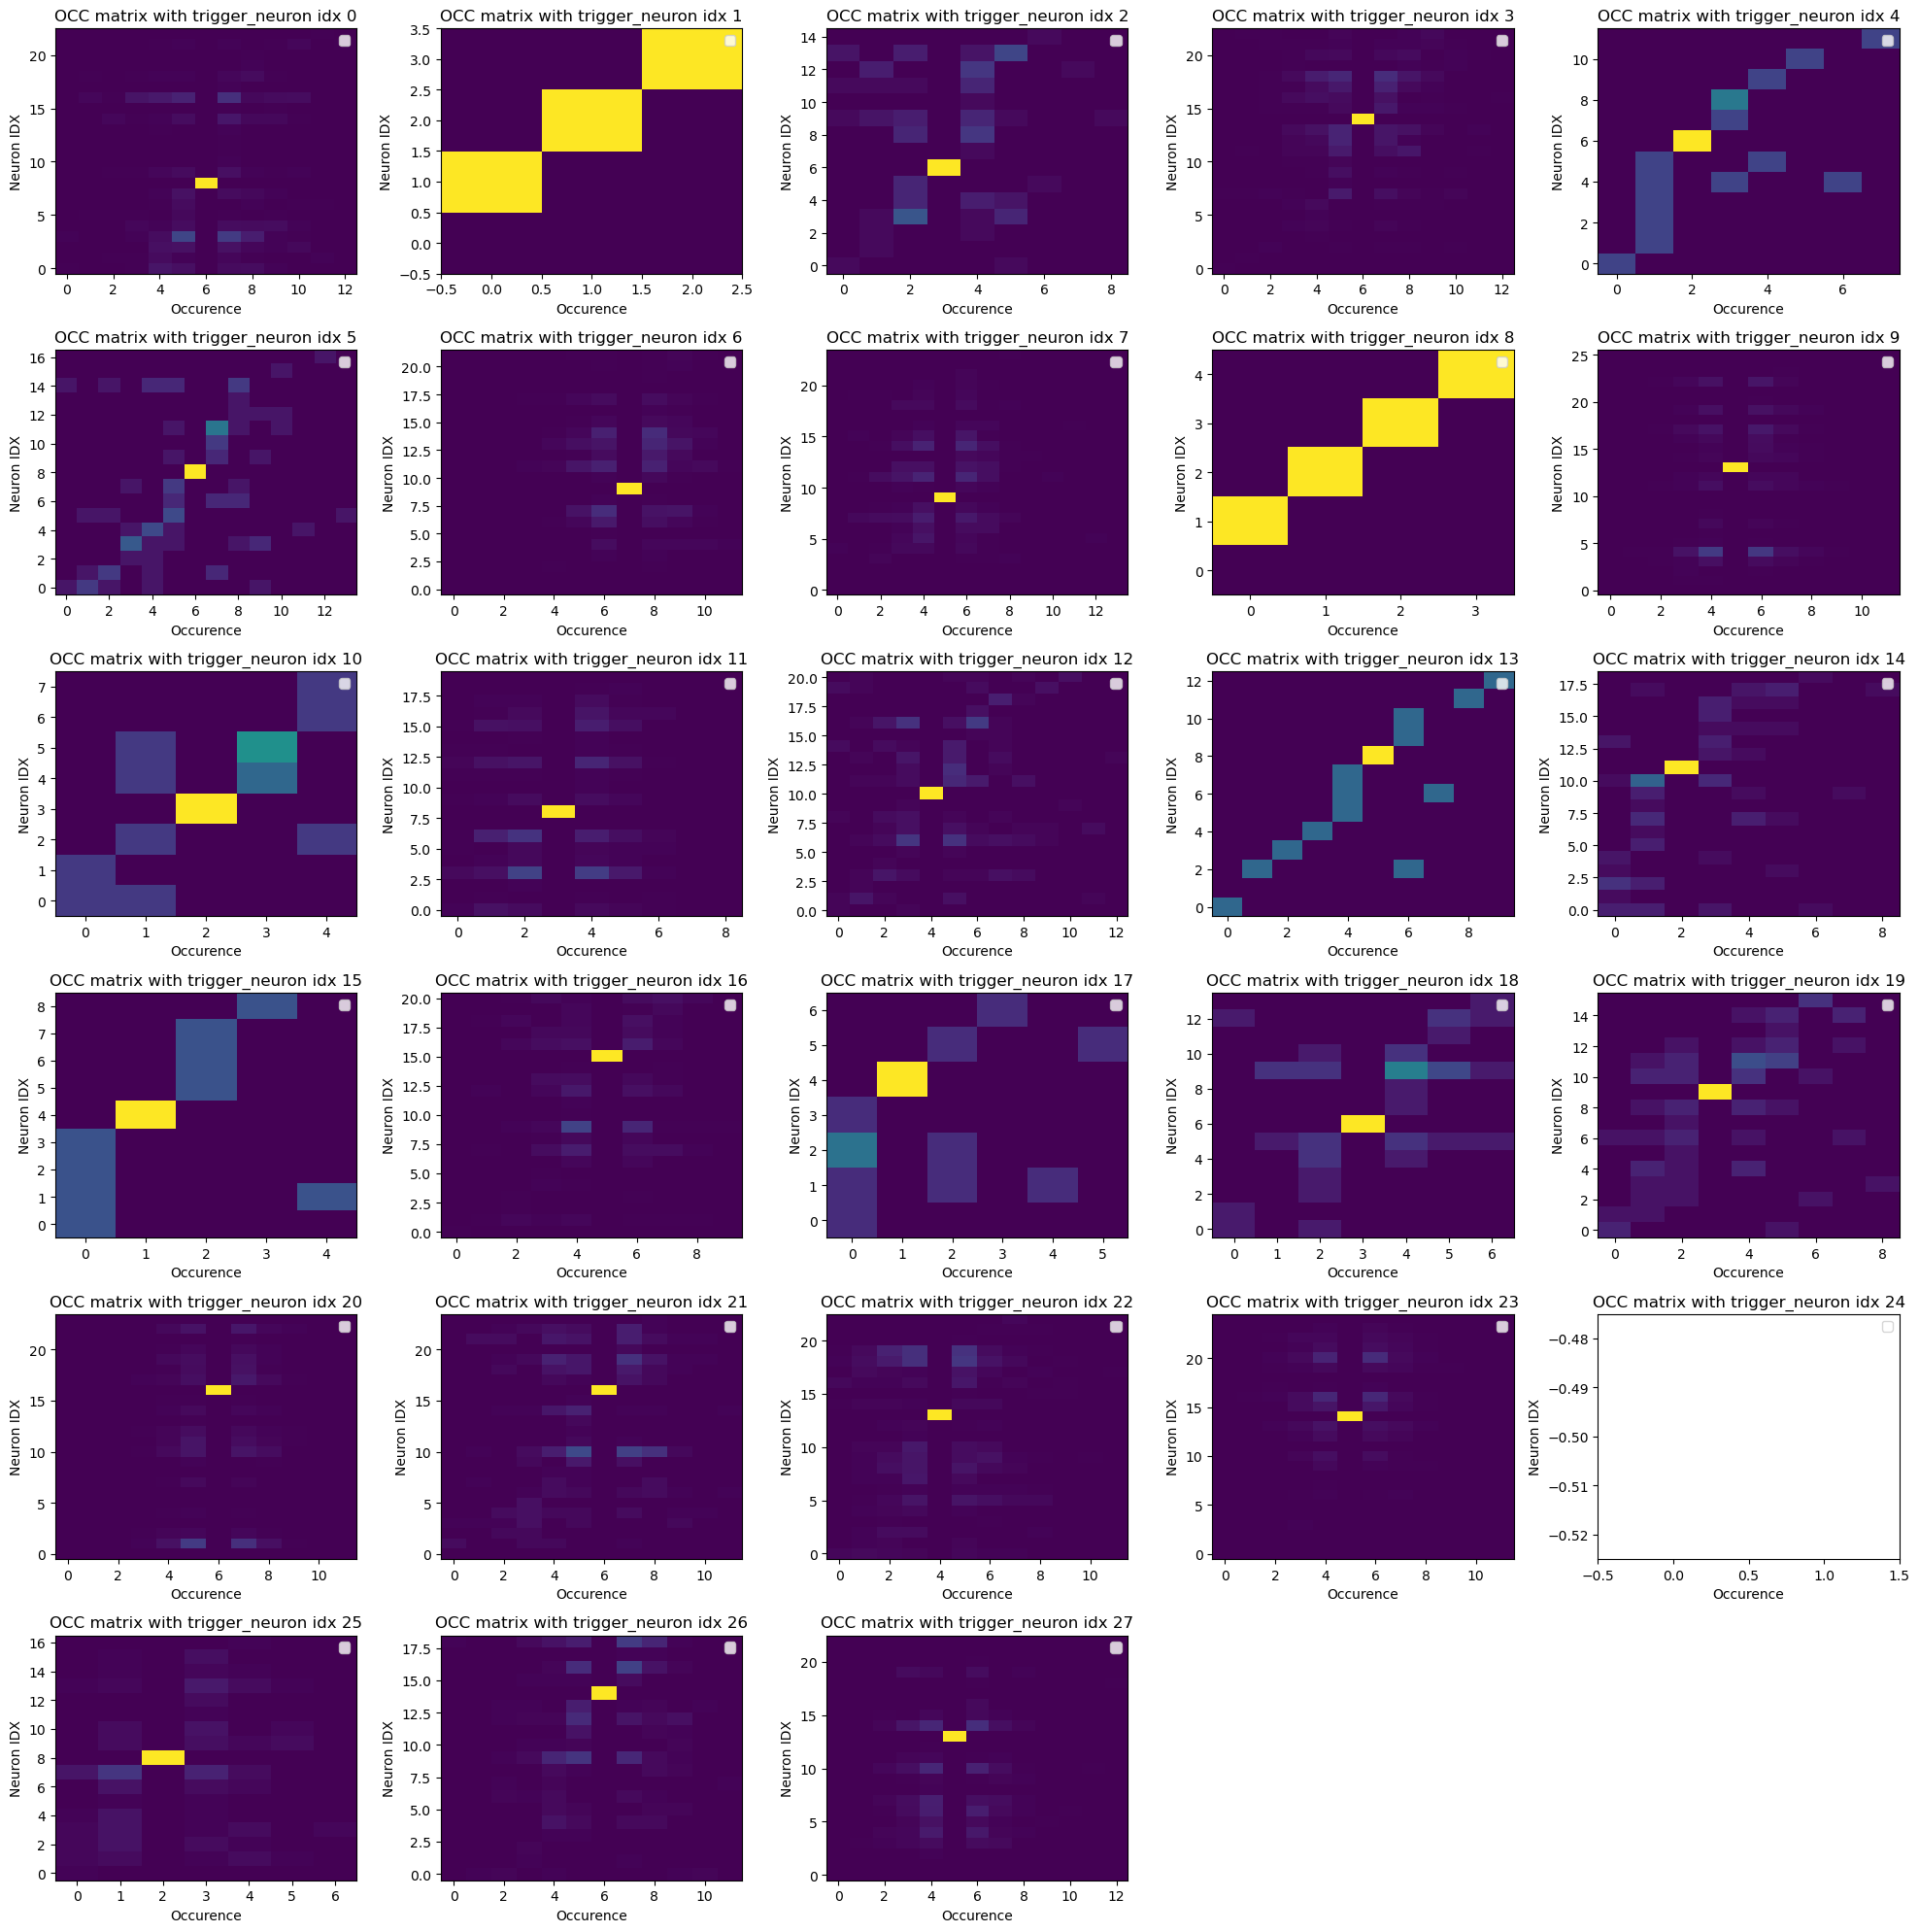

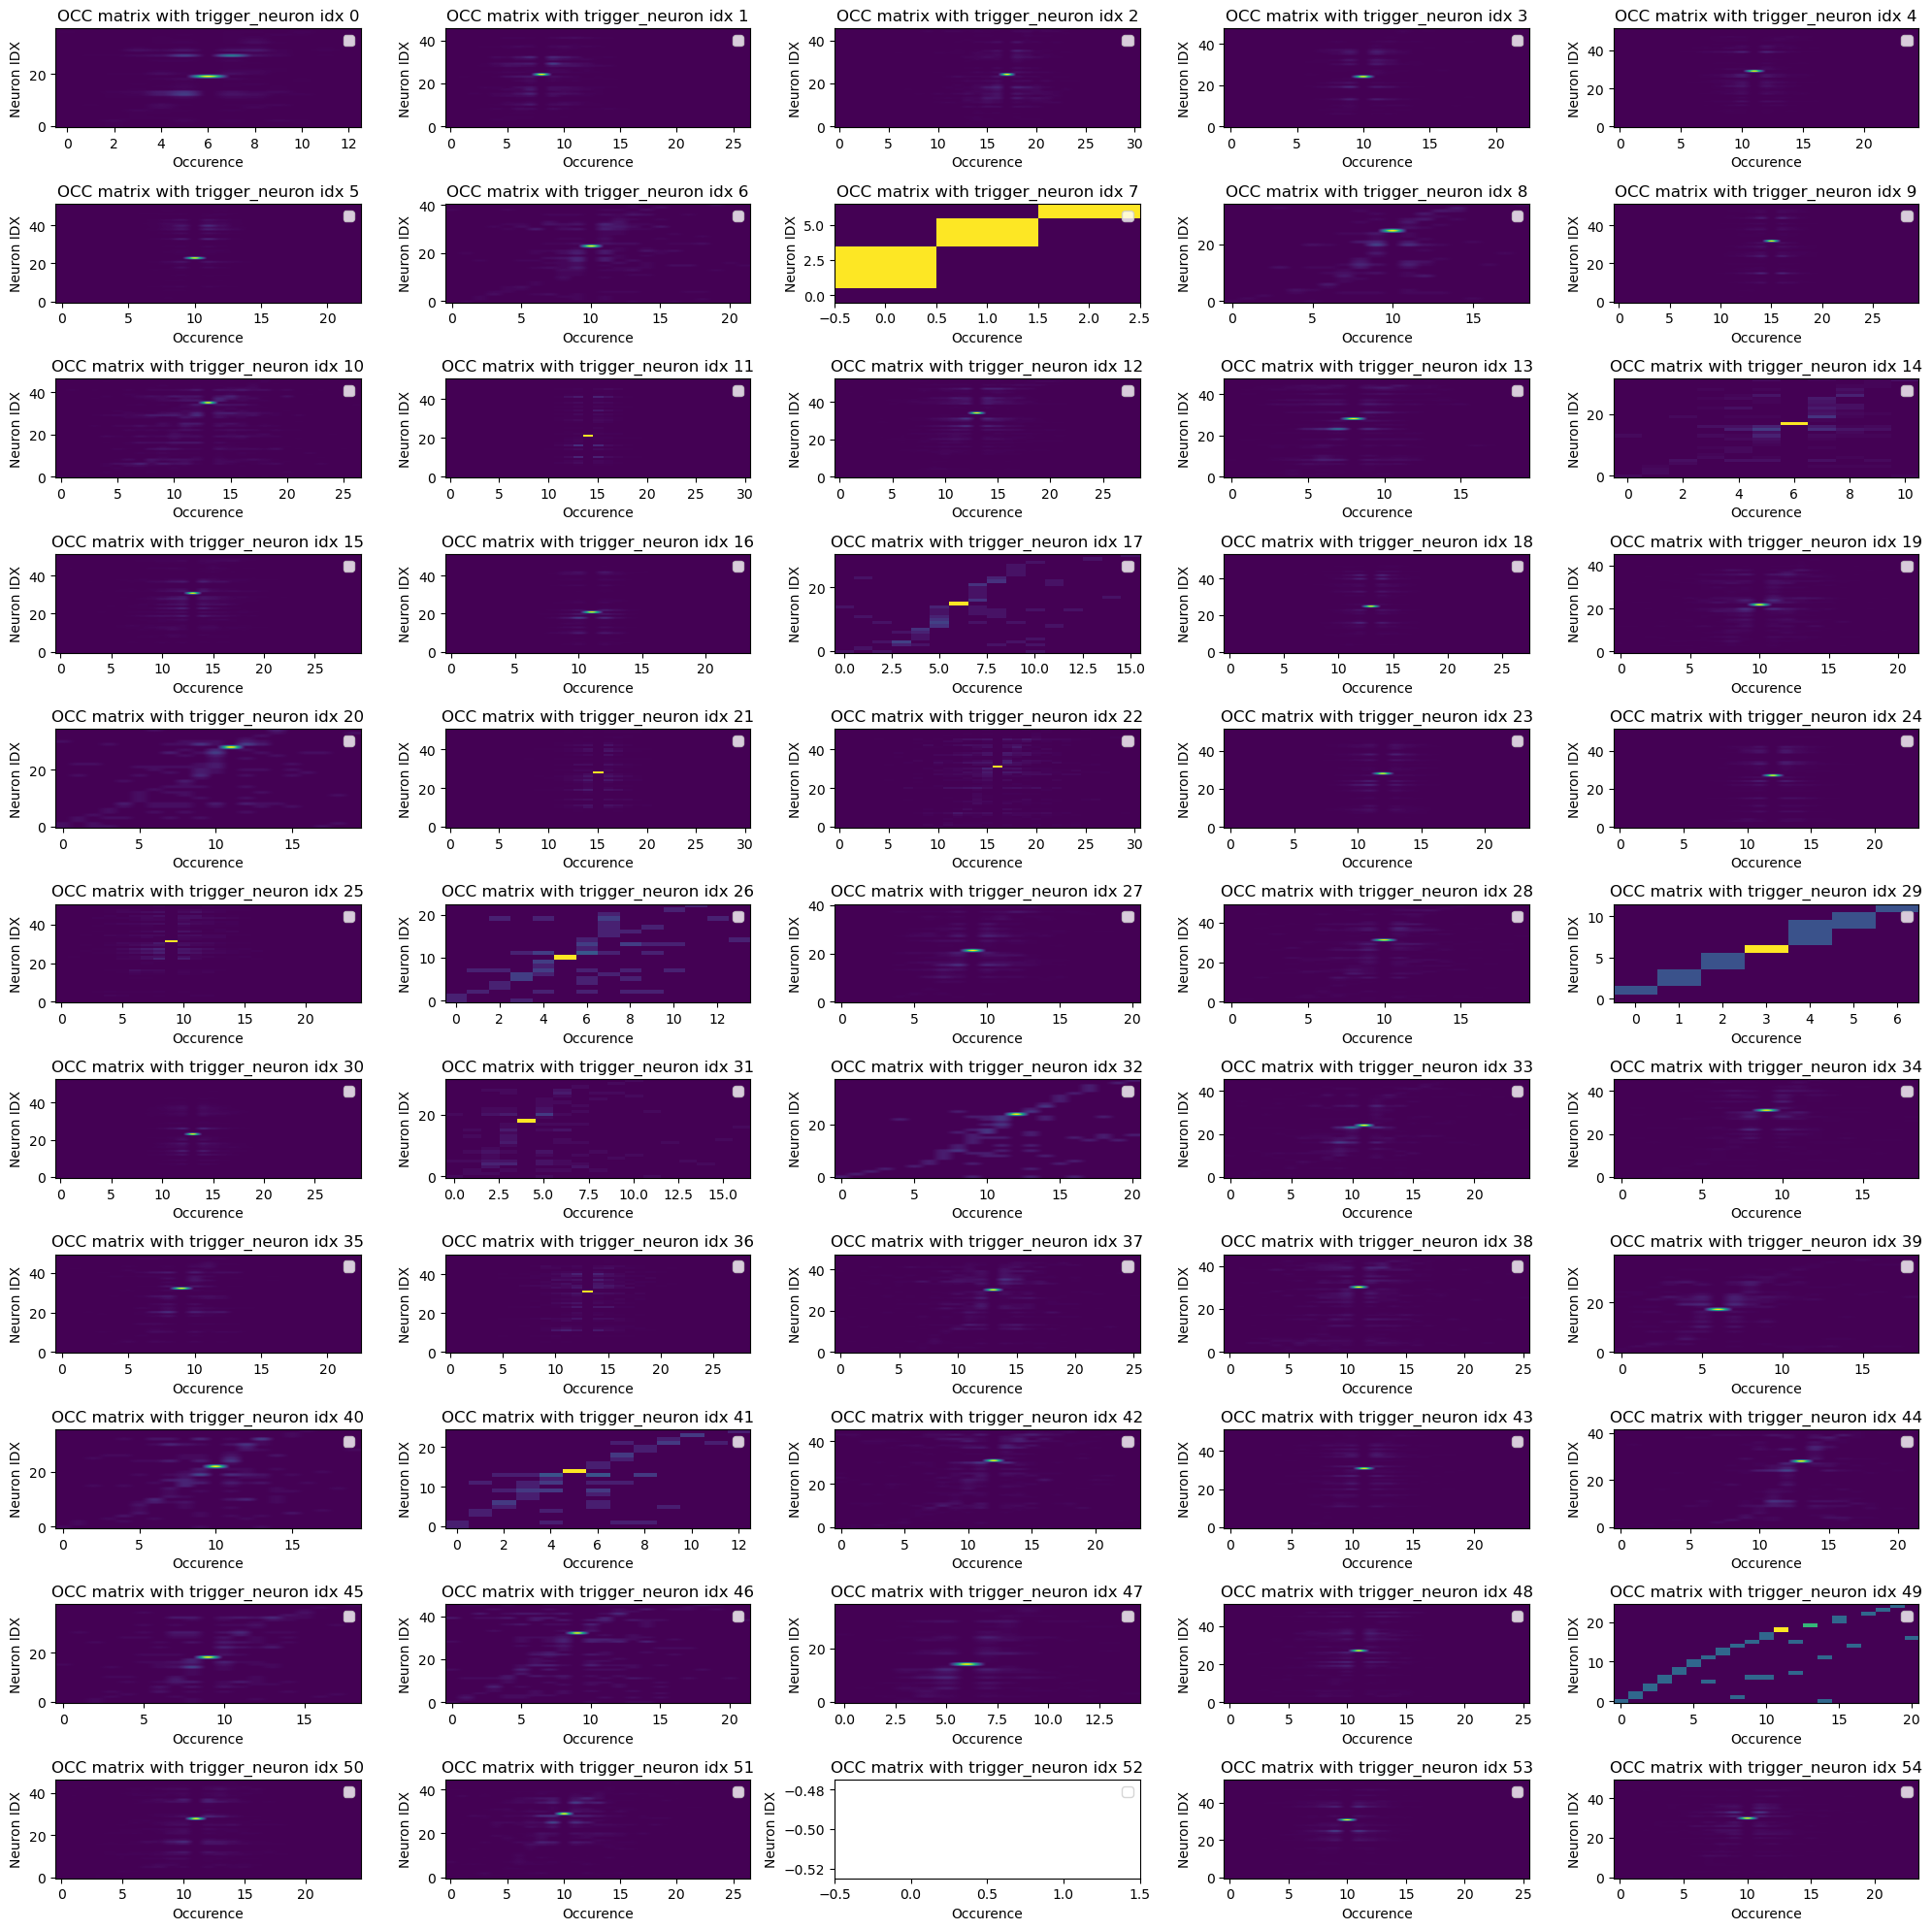

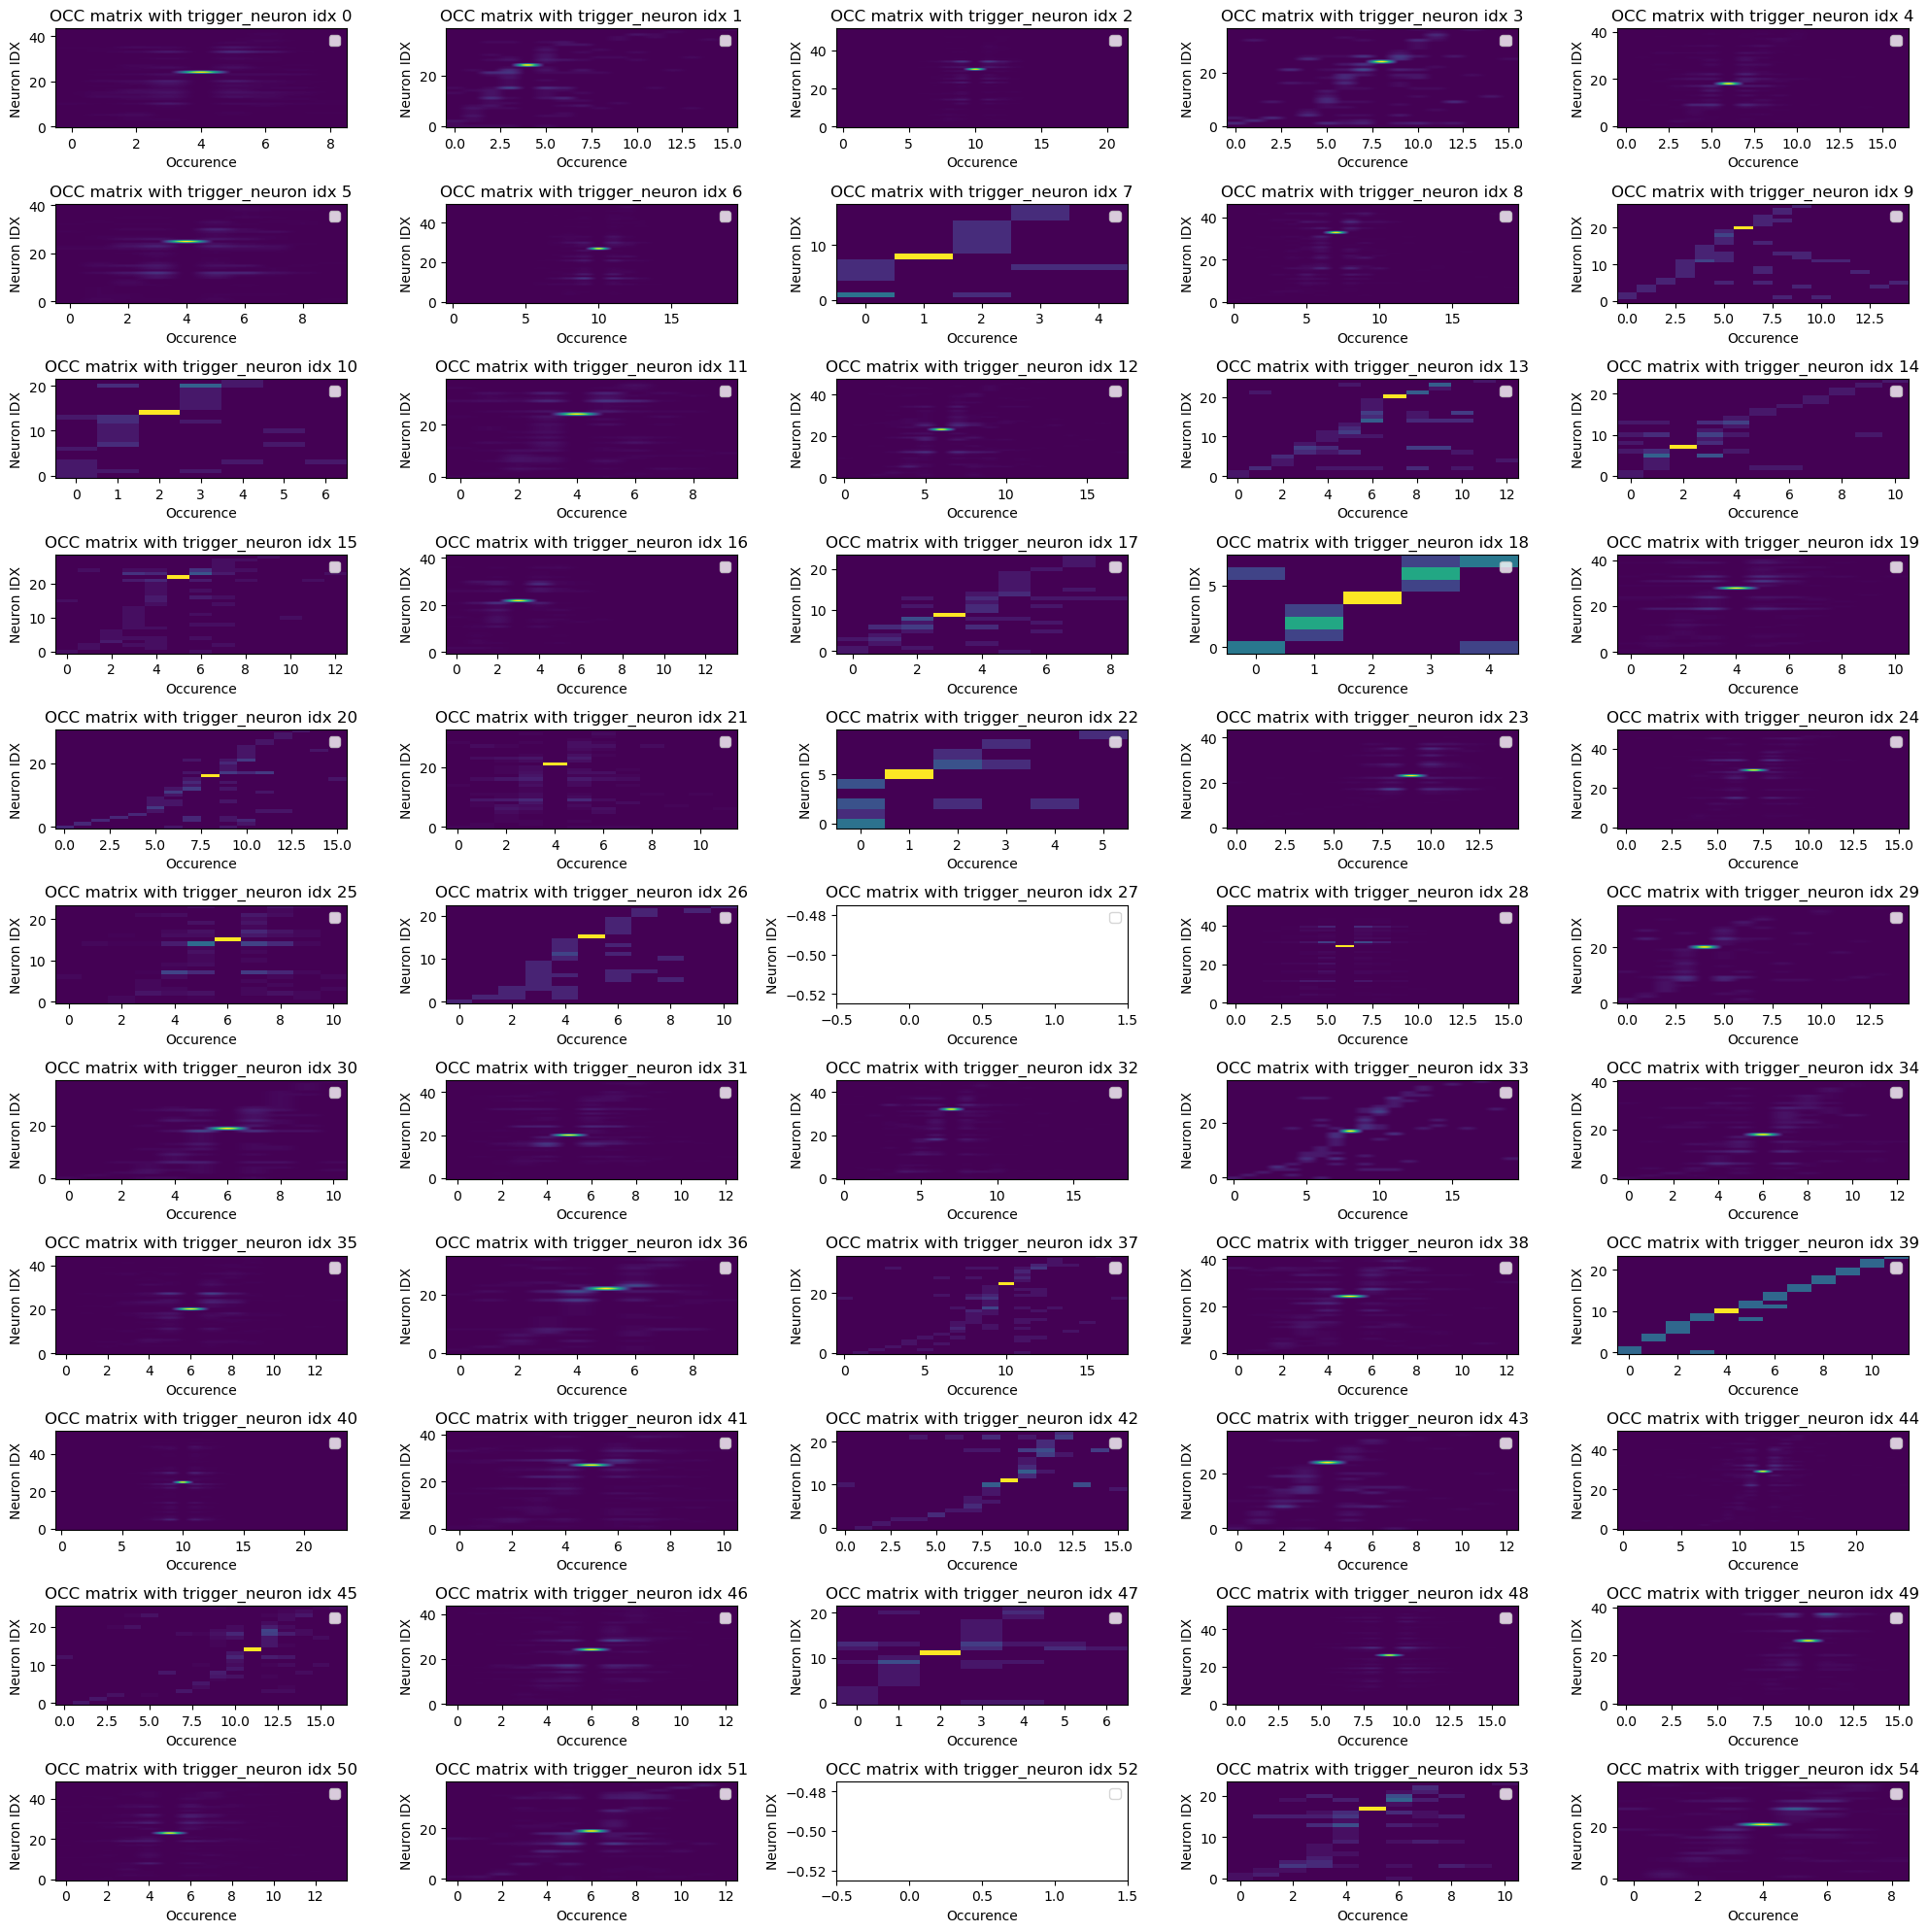

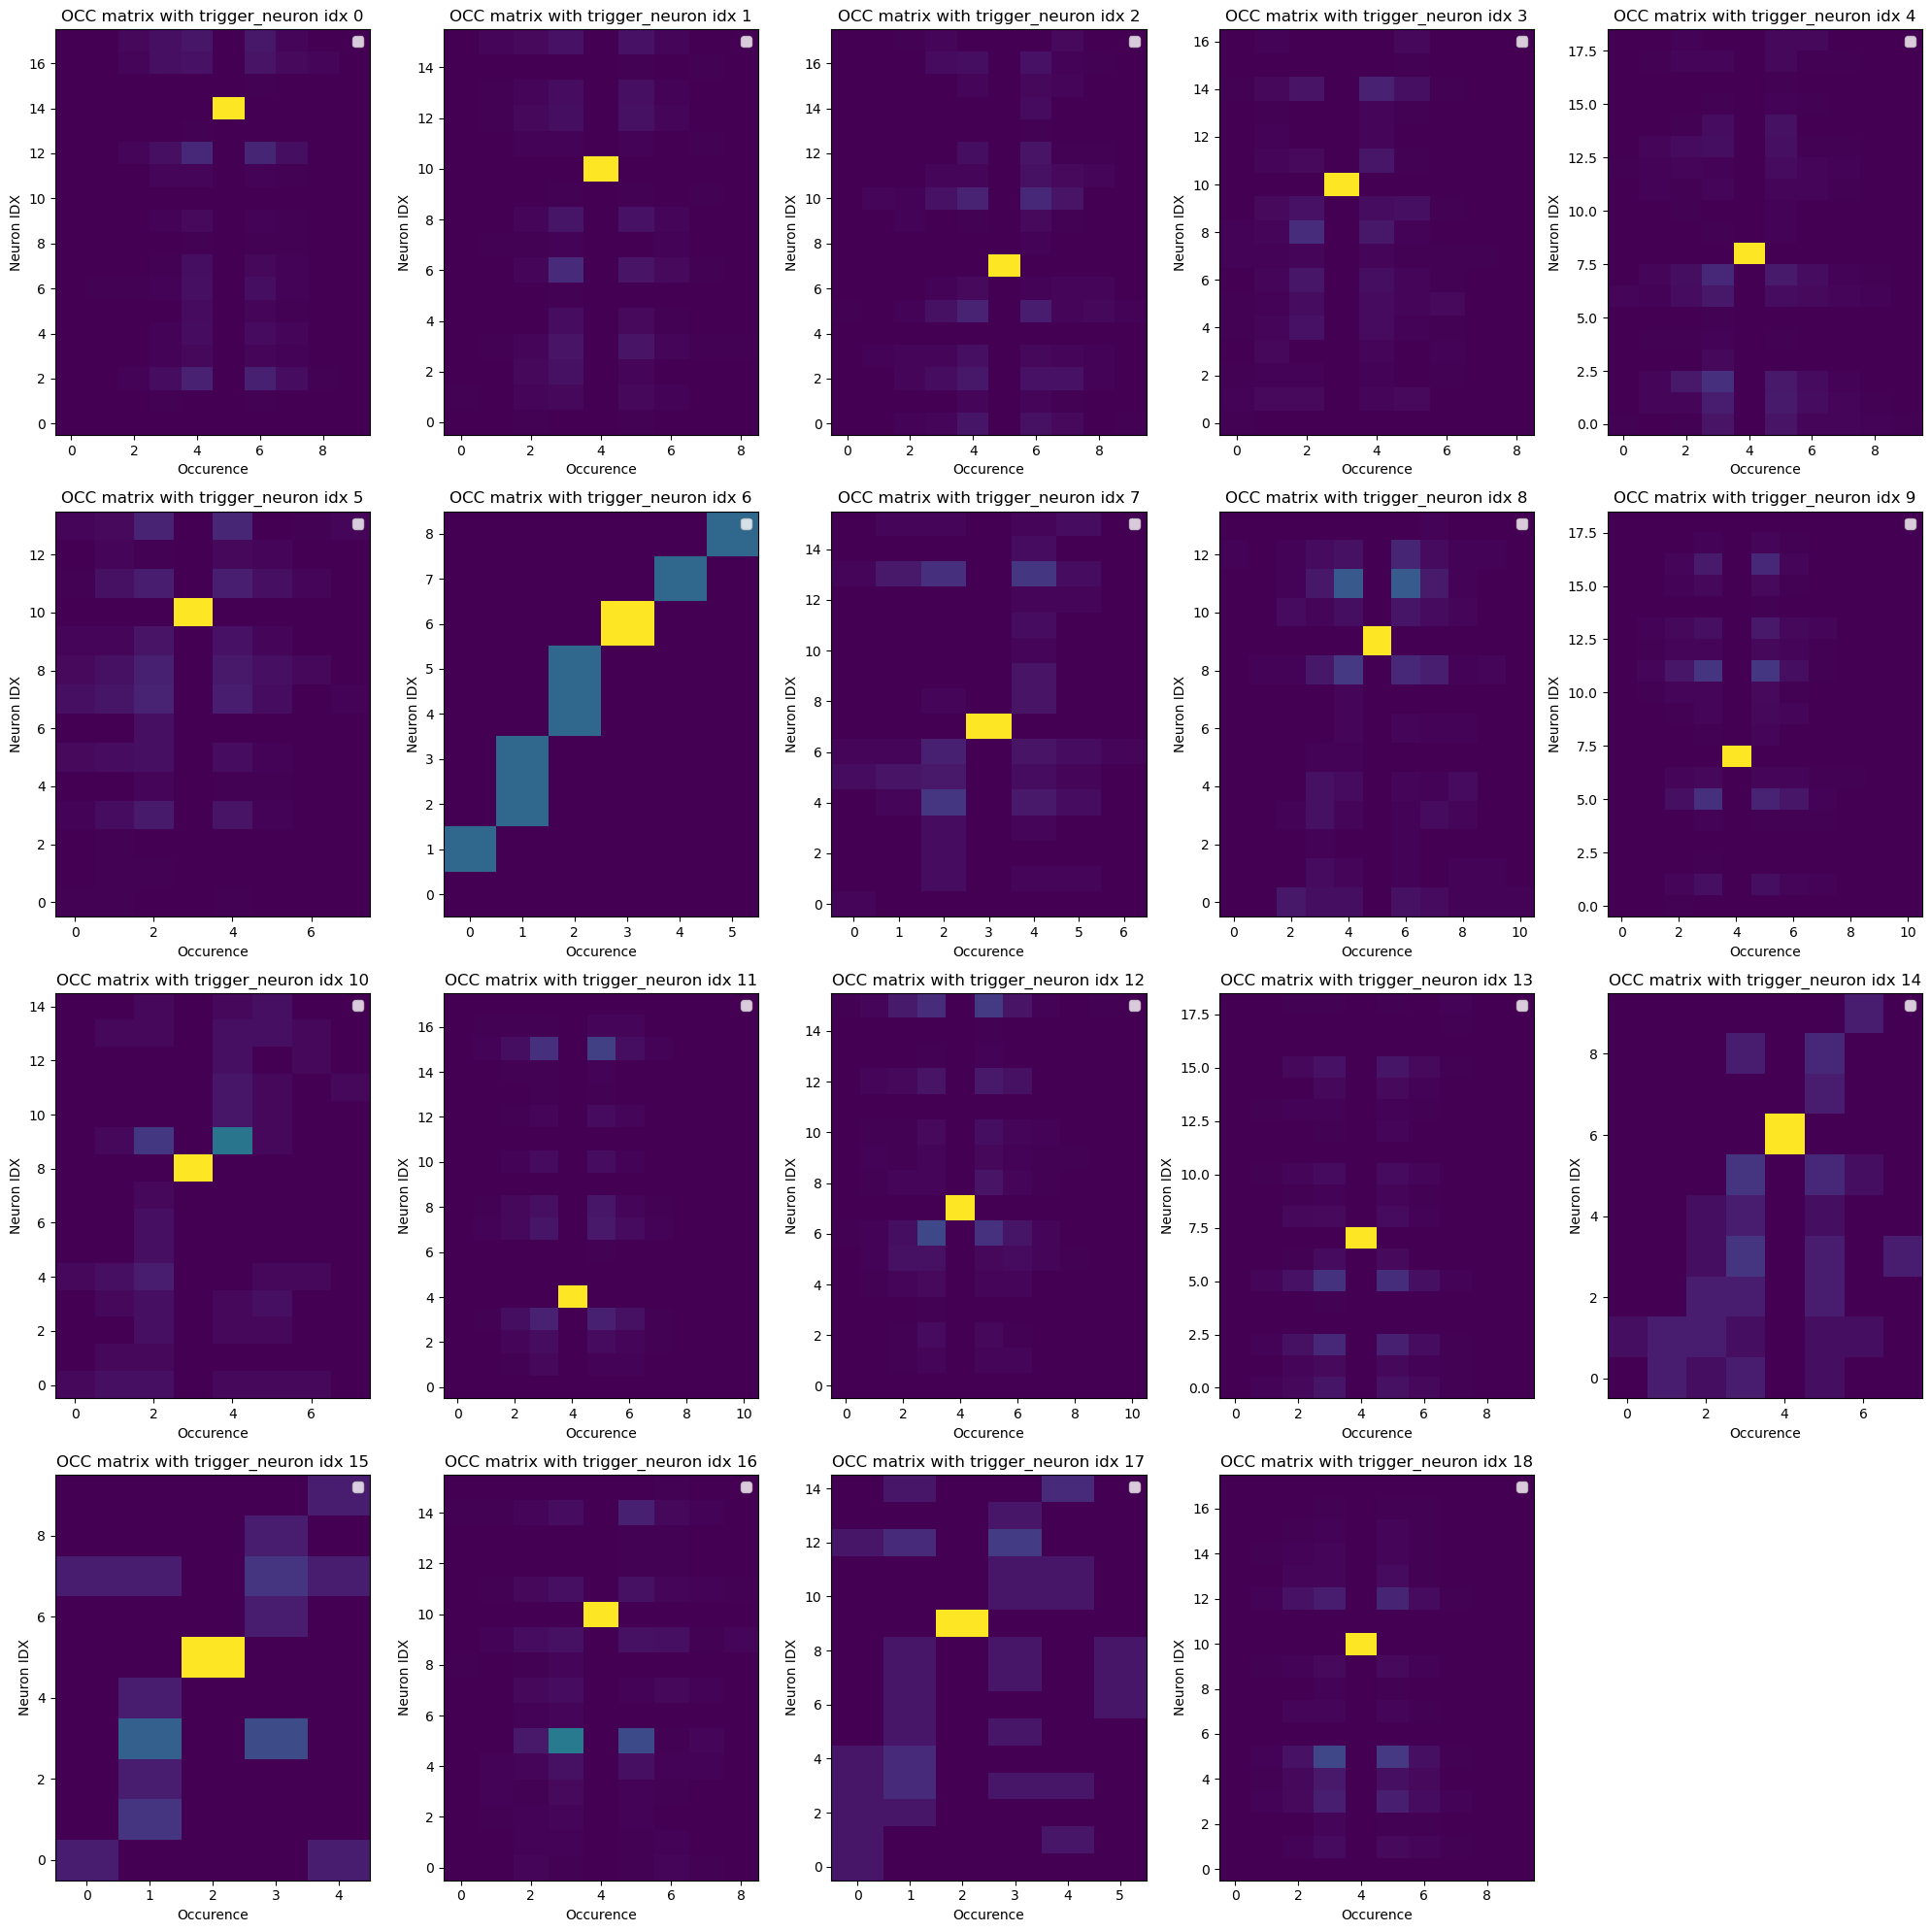

In [62]:
for session, matrices in results_per_session_rat8_middle_split.items():
    occ = matrices["occ"]
    mi_real = matrices["mi_real"]
    surrogates = matrices ["surrogates"]
    boundary = matrices ["boundary"]
    def plot_occs(occ_matrix, ax, neuron_idx):
        ax.imshow(sort_occ_matrix(occ_matrix)[0], aspect='auto', origin='lower')
        ax.set_xlabel('Occurence')
        ax.set_ylabel('Neuron IDX')
        ax.set_title(f'OCC matrix with trigger_neuron idx {neuron_idx}')
        ax.legend()

    num_plots = len(occ)
    cols = 5
    rows = (num_plots + cols - 1) // cols  # Ceiling division
    
    # Create subplots
    fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
    axes = axes.flatten()  # Flatten to make indexing easier
    
    # Loop through and plot
    for i in range(len(occ)):
        plot_occs(occ[i], axes[i], i)
    
    # Hide unused subplots
    for ax in axes[num_plots:]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

/var/folders/gx/7pdzybf540s07y1q49gzn5400000gn/T/ipykernel_6305/807631422.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


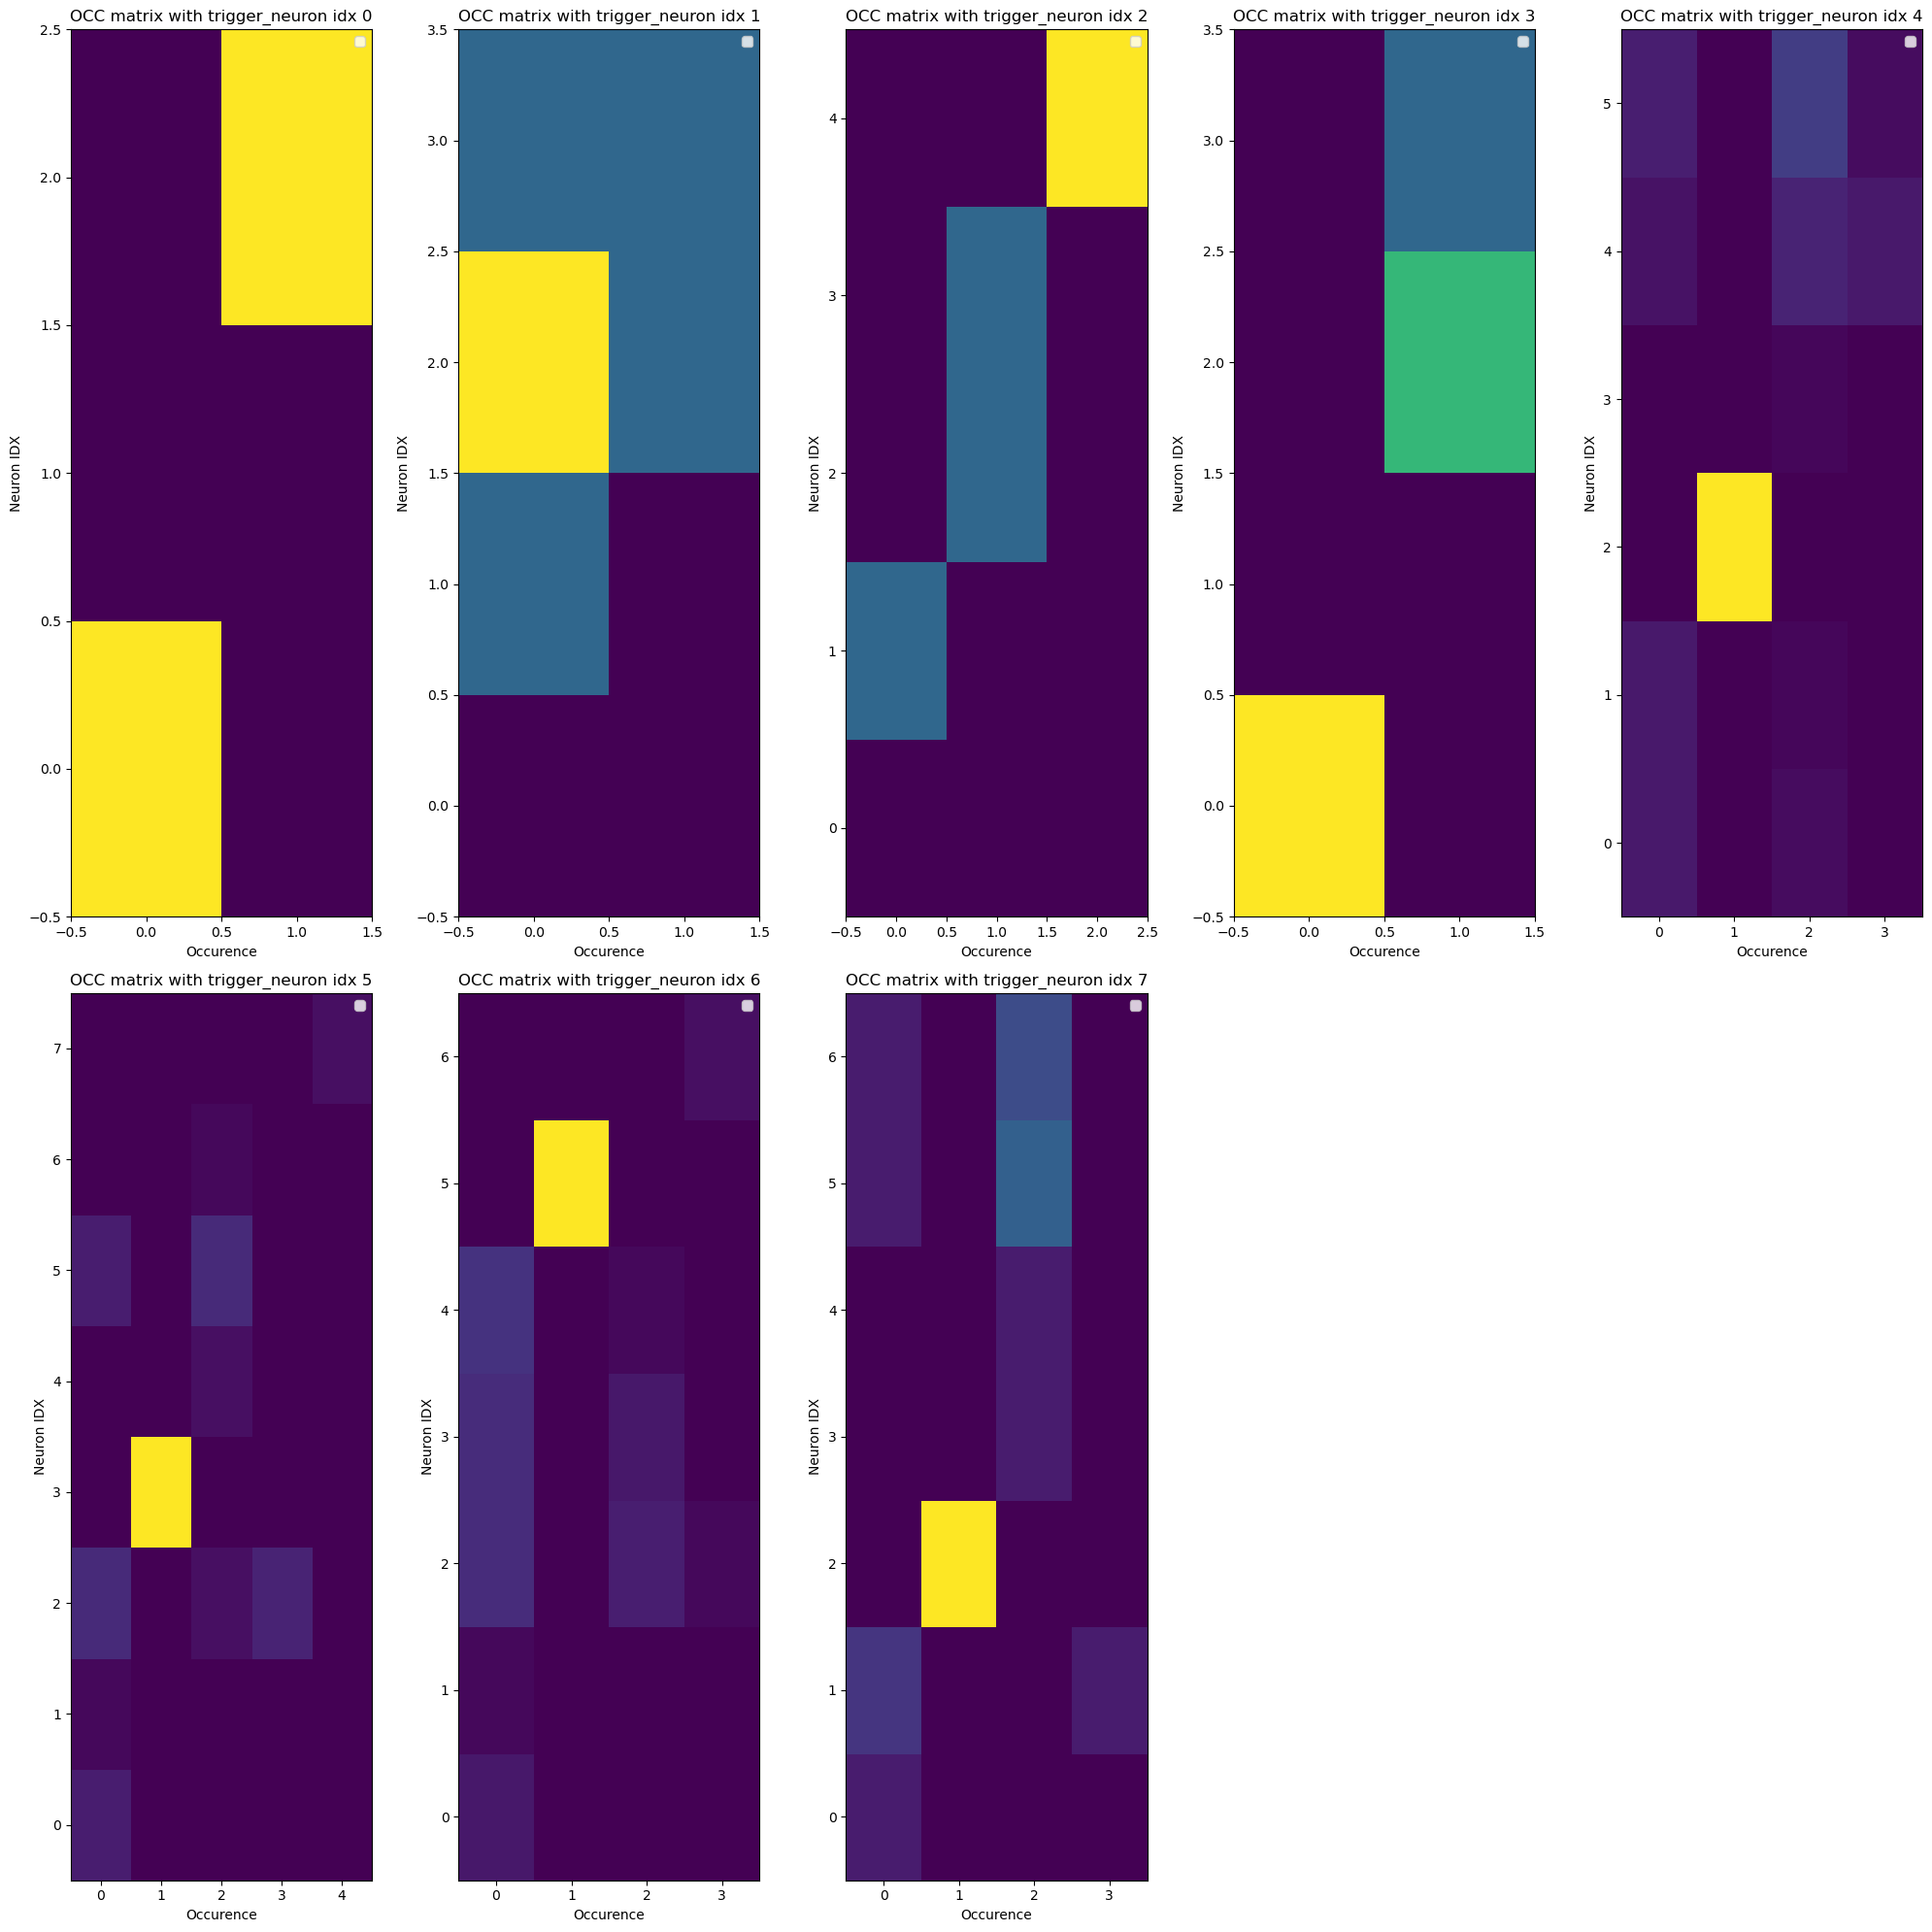

/var/folders/gx/7pdzybf540s07y1q49gzn5400000gn/T/ipykernel_6305/807631422.py:7: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.imshow(sort_occ_matrix(occ_matrix)[0], aspect='auto', origin='lower')


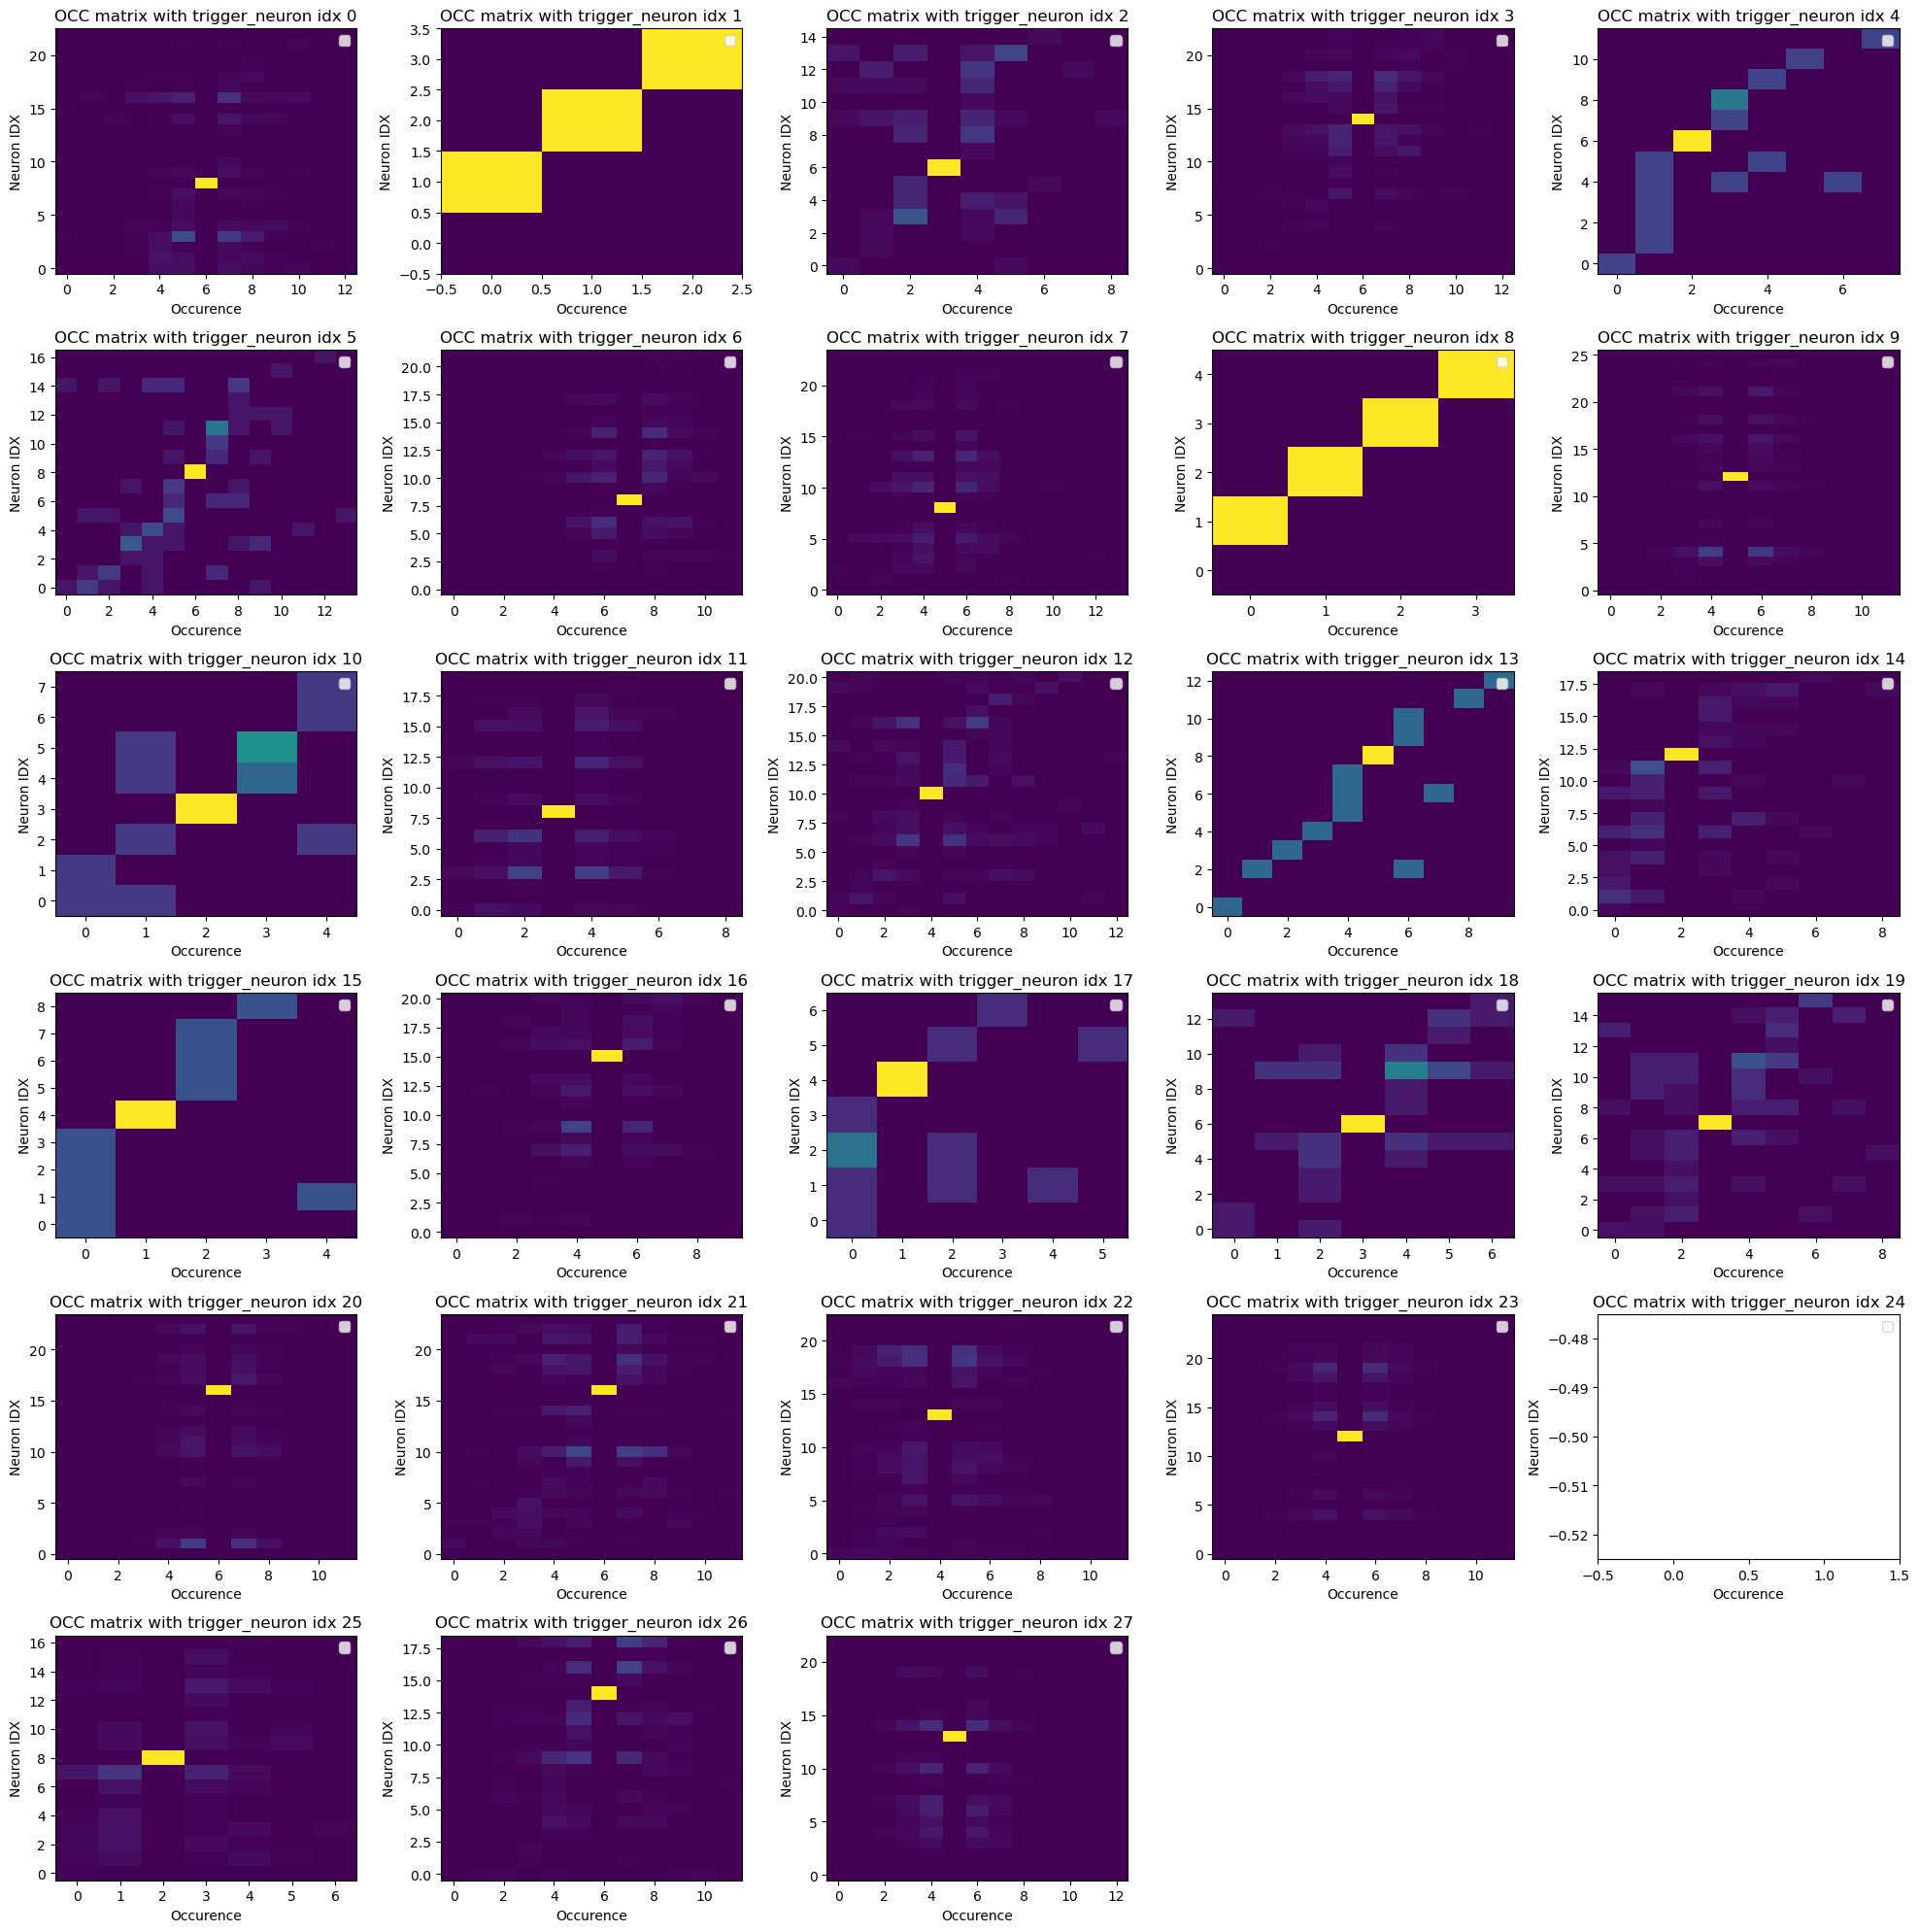

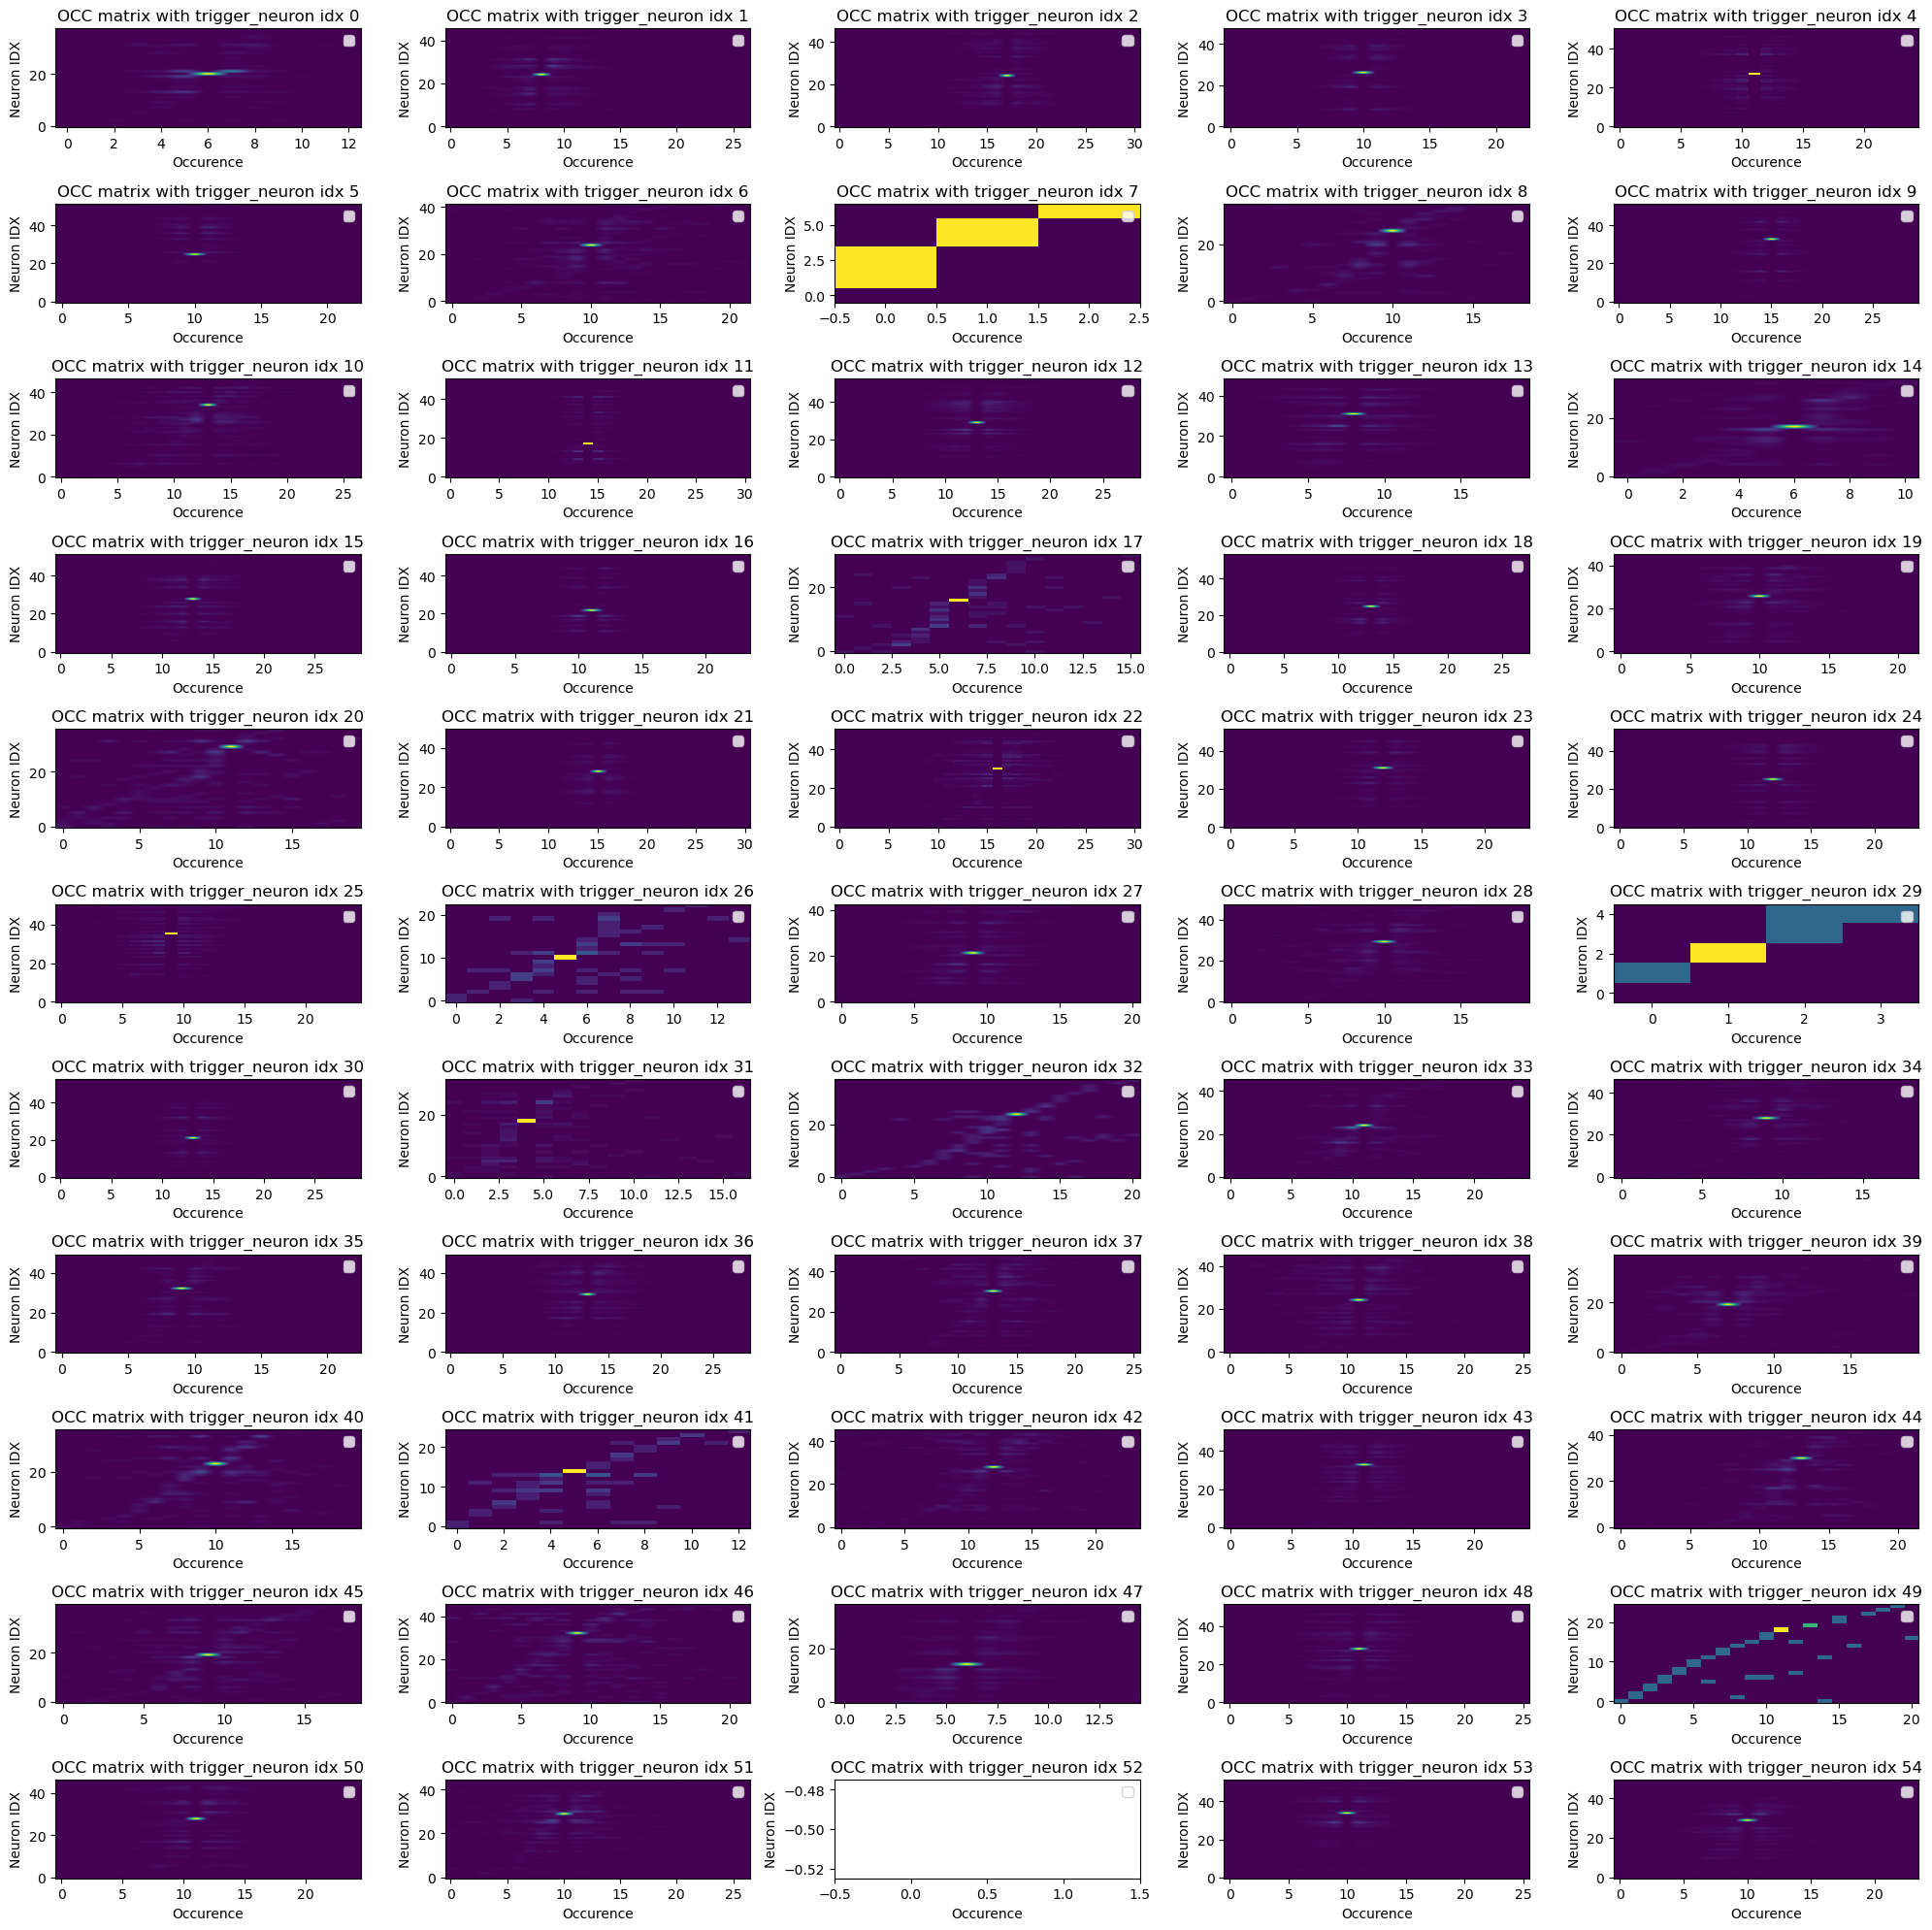

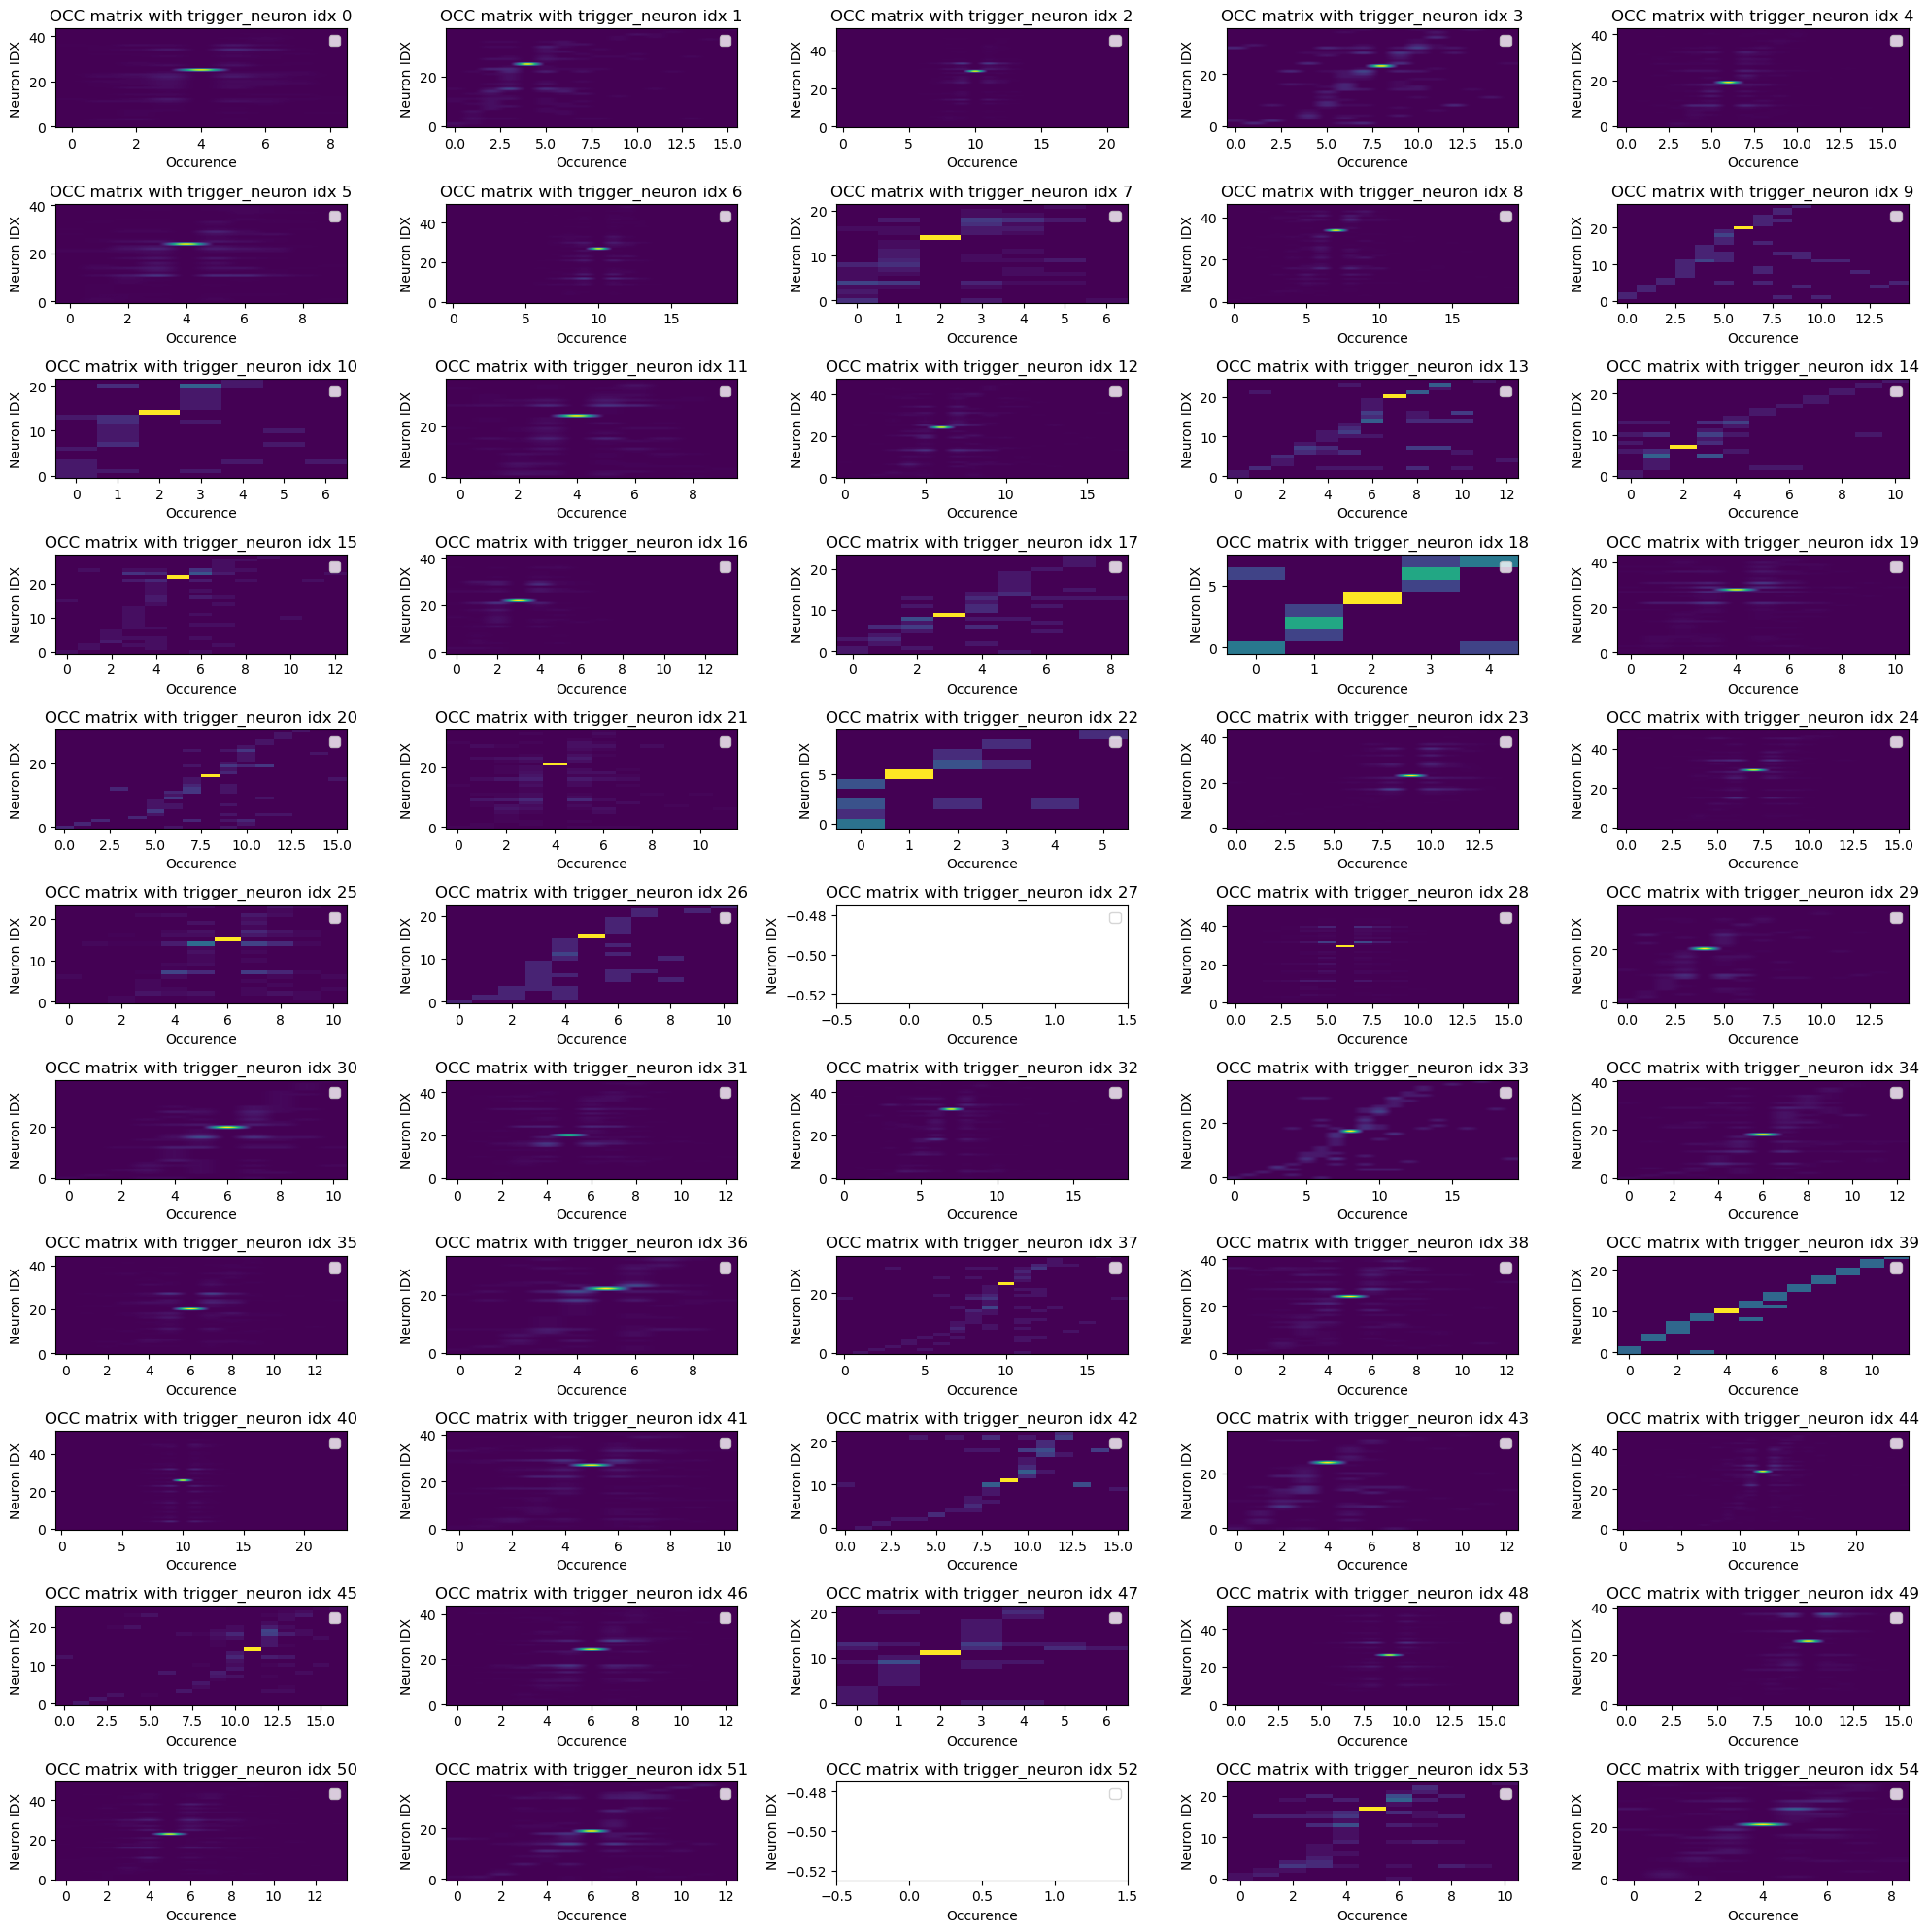

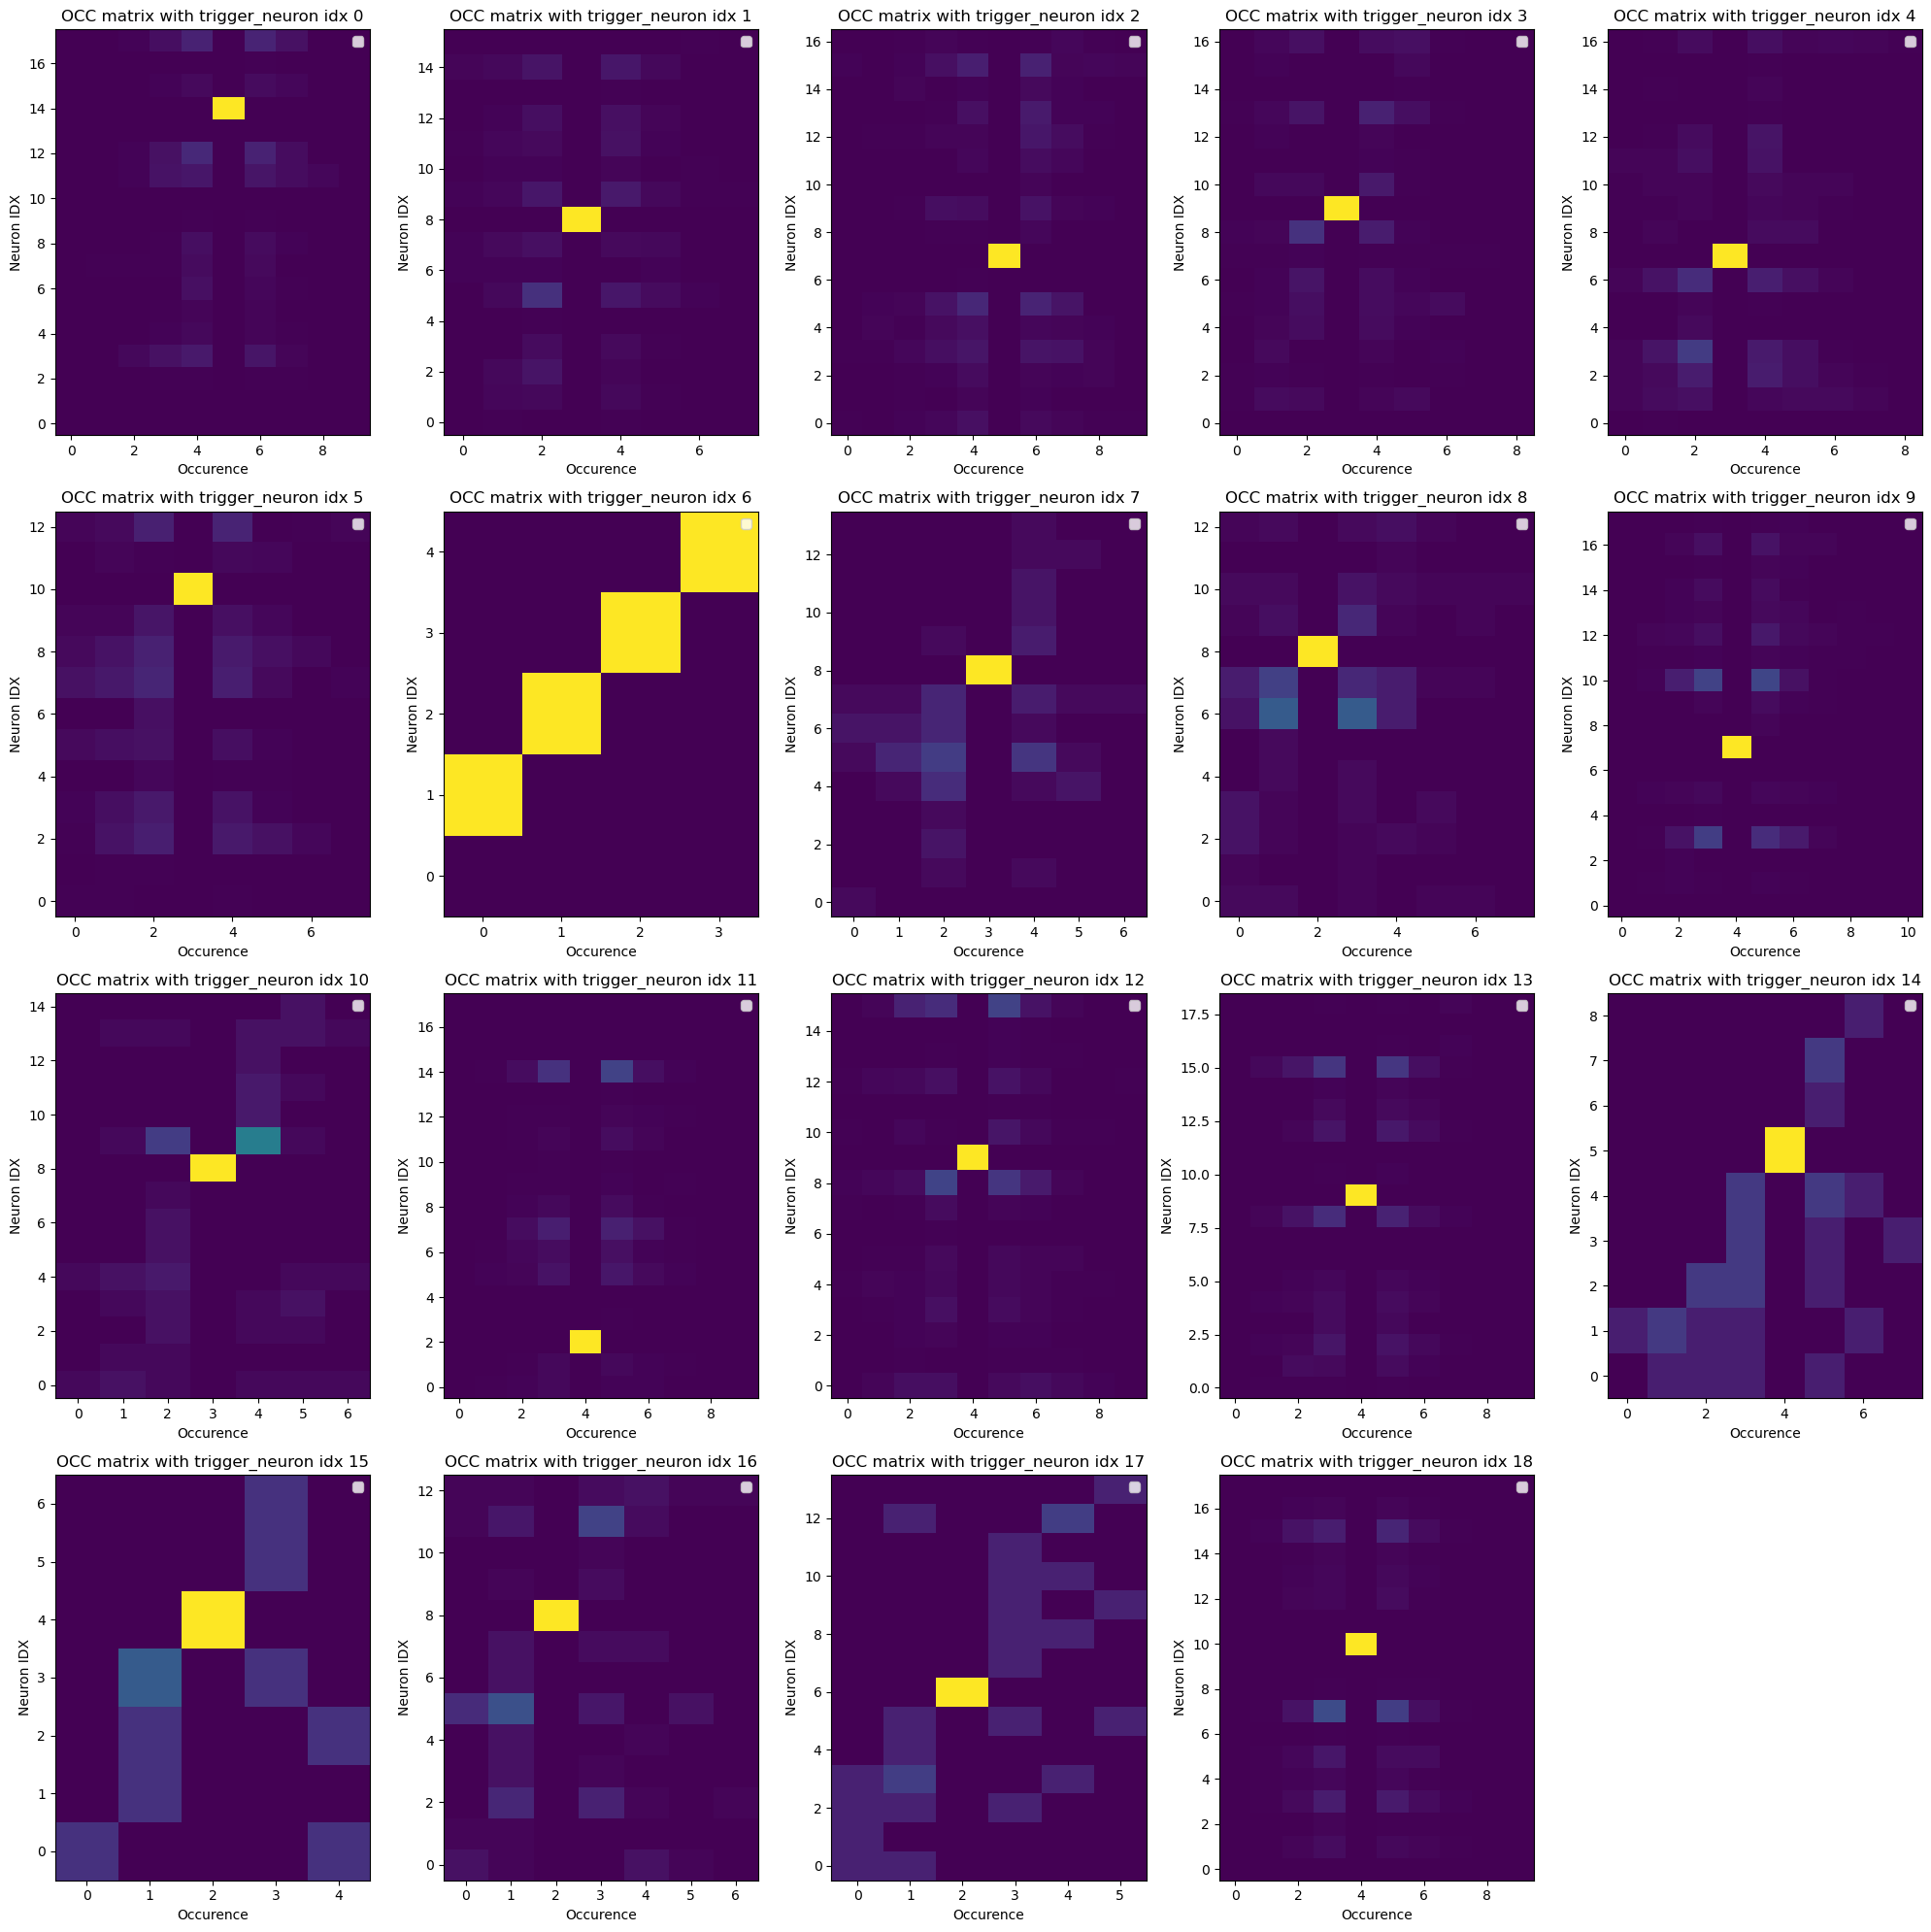

In [29]:
for session, matrices in results_per_session_rat8_third_split.items():
    occ = matrices["occ"]
    mi_real = matrices["mi_real"]
    surrogates = matrices ["surrogates"]
    boundary = matrices ["boundary"]
    def plot_occs(occ_matrix, ax, neuron_idx):
        ax.imshow(sort_occ_matrix(occ_matrix)[0], aspect='auto', origin='lower')
        ax.set_xlabel('Occurence')
        ax.set_ylabel('Neuron IDX')
        ax.set_title(f'OCC matrix with trigger_neuron idx {neuron_idx}')
        ax.legend()

    num_plots = len(occ)
    cols = 5
    rows = (num_plots + cols - 1) // cols  # Ceiling division
    
    # Create subplots
    fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
    axes = axes.flatten()  # Flatten to make indexing easier
    
    # Loop through and plot
    for i in range(len(occ)):
        plot_occs(occ[i], axes[i], i)
    
    # Hide unused subplots
    for ax in axes[num_plots:]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

In [34]:
%run Results_analysis_functions.ipynb

In [35]:
results_analysis_rat8_third_split = {}

In [78]:
for session, matrices in results_per_session_rat8_third_split.items():
    try:
        occ = matrices["occ"]
        mi_real = matrices["mi_real"]
        surrogates = matrices ["surrogates"]
        boundary = matrices ["boundary"]
        test_matrix = session_data_rat8_third_split[session]["test_matrix"]
        n_neurons = len(boundary)
        significant_neurons = get_significant_neurons(mi_real, boundary)
        print(session)
    
        if np.all(np.isnan(significant_neurons)):
            print(f'There are no significant neurons for session {session}')
            continue
           
        else: 
            rank_distribution, indices_sig_neur = get_significant_ranks(occ, significant_neurons)
            print(len(indices_sig_neur))
            mean_ranks = np.nanmean(rank_distribution, axis=1)
            # plot_ranks_distribution(mean_ranks, indices_sig_neur, session)
            mean_ranks_sequence, neurons_idx_sequence = mean_ranks_to_seq(mean_ranks, indices_sig_neur)
        
            pattern_template_ = create_occ_pattern_template(occ, significant_neurons, neurons_idx_sequence)
            #slice it to the number of neurons
            pattern_template = pattern_template_[:n_neurons]
            values_first_half, time_points_first_half = get_weighted_values(test_matrix, pattern_template, window_size=120, step_size=30, first_half = True)
            values_second_half, time_points_second_half = get_weighted_values(test_matrix, pattern_template, window_size=120, step_size=30, first_half = False)
            
            results_analysis_rat8_third_split[session] = {
            "pattern_template": pattern_template,
            "values_first_half": values_first_half,
            "time_points_first_half": time_points_first_half,
            "time_points_second_half": time_points_second_half,
            "values_second_half" : values_second_half
            }
            
    except:
        print(f'{session} gave an error')


Rat08-20130708
4
Rat08-20130708 gave an error
Rat08-20130709
21
Rat08-20130709 gave an error
Rat08-20130712


/var/folders/gx/7pdzybf540s07y1q49gzn5400000gn/T/ipykernel_6305/3490290448.py:19: RuntimeWarning: Mean of empty slice
  mean_ranks = np.nanmean(rank_distribution, axis=1)


43
Test run 1: 49 empty spike matrices out of 537 total time points. Fraction of empty: 0.0912
Test run 2: 103 empty spike matrices out of 764 total time points. Fraction of empty: 0.1348
Test run 3: 149 empty spike matrices out of 927 total time points. Fraction of empty: 0.1607
Test run 4: 737 empty spike matrices out of 4809 total time points. Fraction of empty: 0.1533
Test run 5: 756 empty spike matrices out of 7107 total time points. Fraction of empty: 0.1064
Test run 6: 527 empty spike matrices out of 4342 total time points. Fraction of empty: 0.1214
Test run 1: 0 empty spike matrices out of 27 total time points. Fraction of empty: 0.0000
Test run 2: 0 empty spike matrices out of 26 total time points. Fraction of empty: 0.0000
Test run 3: 4 empty spike matrices out of 33 total time points. Fraction of empty: 0.1212
Test run 4: 0 empty spike matrices out of 21 total time points. Fraction of empty: 0.0000
Test run 5: 0 empty spike matrices out of 17 total time points. Fraction of e

In [48]:
results_analysis_rat8_middle_split = {}

In [124]:
for session, matrices in results_per_session_rat8_middle_split.items():
    try:
        occ = matrices["occ"]
        mi_real = matrices["mi_real"]
        surrogates = matrices ["surrogates"]
        boundary = matrices ["boundary"]
        test_matrix = session_data_rat8_middle_split[session]["test_matrix"]
        n_neurons = len(boundary)
        significant_neurons = get_significant_neurons(mi_real, boundary)
        print(session)
    
        if np.all(np.isnan(significant_neurons)):
            print(f'There are no significant neurons for session {session}')
            continue
           
        else: 
            rank_distribution, indices_sig_neur = get_significant_ranks(occ, significant_neurons)
            print(indices_sig_neur)
            mean_ranks = np.nanmean(rank_distribution, axis=1)
            # plot_ranks_distribution(mean_ranks, indices_sig_neur, session)
            mean_ranks_sequence, neurons_idx_sequence = mean_ranks_to_seq(mean_ranks, indices_sig_neur)
        
            pattern_template_ = create_occ_pattern_template(occ, significant_neurons, neurons_idx_sequence)
            #slice it to the number of neurons
            pattern_template = pattern_template_[:n_neurons]
            values_first_half, time_points_first_half = get_weighted_values(test_matrix, pattern_template, window_size=120, step_size=30, first_half = True)
            values_second_half, time_points_second_half = get_weighted_values(test_matrix, pattern_template, window_size=120, step_size=30, first_half = False)
            
            results_analysis_rat8_middle_split[session] = {
            "pattern_template": pattern_template,
            "values_first_half": values_first_half,
            "time_points_first_half": time_points_first_half,
            "time_points_second_half": time_points_second_half,
            "values_second_half" : values_second_half,
            "significant_neurons" : significant_neurons
            }
            
    except:
        print(f'{session} gave an error')


Rat08-20130708
[0 2 5 7]
Rat08-20130708 gave an error
Rat08-20130709
[ 0  1  2  3  5  6  7  8  9 11 12 14 16 17 19 20 21 22 23 26 27]


/var/folders/gx/7pdzybf540s07y1q49gzn5400000gn/T/ipykernel_6305/4280836459.py:19: RuntimeWarning: Mean of empty slice
  mean_ranks = np.nanmean(rank_distribution, axis=1)


Test run 1: 8066 empty spike matrices out of 12825 total time points. Fraction of empty: 0.6289
Test run 2: 2663 empty spike matrices out of 4576 total time points. Fraction of empty: 0.5819
Test run 1: 7470 empty spike matrices out of 15839 total time points. Fraction of empty: 0.4716
Test run 2: 84 empty spike matrices out of 92 total time points. Fraction of empty: 0.9130
Rat08-20130712
[ 0  1  2  4  5  7  8  9 10 11 12 13 14 15 16 17 18 19 21 22 23 24 25 27
 28 30 33 35 36 37 38 39 40 42 43 44 45 47 48 50 51 53 54]
Test run 1: 146 empty spike matrices out of 475 total time points. Fraction of empty: 0.3074
Test run 2: 222 empty spike matrices out of 690 total time points. Fraction of empty: 0.3217
Test run 3: 302 empty spike matrices out of 889 total time points. Fraction of empty: 0.3397
Test run 4: 1772 empty spike matrices out of 4770 total time points. Fraction of empty: 0.3715
Test run 5: 2630 empty spike matrices out of 4198 total time points. Fraction of empty: 0.6265
Test r

In [56]:
import pickle

# Save to file
with open("results_rat_8_middle.pkl", "wb") as pkl_file:
    pickle.dump(results_analysis_rat8_middle_split, pkl_file)

# Save to file
with open("rat8_means_midle_first.pkl", "wb") as pkl_file:
    pickle.dump(means_first_middle, pkl_file)

with open("rat8_means_midle_second.pkl", "wb") as pkl_file:
    pickle.dump(means_second_middle, pkl_file)

In [131]:

# Save to file
with open("rat8_results_third_split", "wb") as pkl_file:
    pickle.dump(results_per_session_rat8_third_split, pkl_file)

with open("rat8_results_middle_split", "wb") as pkl_file:
    pickle.dump(results_per_session_rat8_middle_split, pkl_file)


In [130]:
with open("rat8_results_across_sessions", "wb") as pkl_file:
    pickle.dump(rat8_across_sessions, pkl_file)